In [2]:
# ========================================
# EVALUATION FRAMEWORK - SETUP CELL
# Run this first in every notebook
# ========================================

# 1. Mount Google Drive (for data persistence)
from google.colab import drive
drive.mount('/content/drive')

# 2. Set working directory
import os
WORK_DIR = '/content/drive/MyDrive/adults-only-data_preparation_project_2026'
os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)

# Create folder structure
os.makedirs('data/baseline', exist_ok=True)
os.makedirs('data/corrupted', exist_ok=True)
os.makedirs('data/cleaned', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print(f"✅ Working directory: {WORK_DIR}")
print(f"✅ Folder structure created")

# 3. Install required packages
# !pip install -q tensorflow-data-validation  # For Part 2
!pip install -q statsmodels  # For Part 3 (McNemar's test)

# 4. Import common libraries
# import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from scipy.stats import ttest_rel, ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries loaded")
print("=" * 50)

KeyboardInterrupt: 

In [2]:
!pip install datasets scikit-learn pandas numpy setuptools -q

In [3]:
!pip install jenga

In [4]:
import pandas as pd
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import os

class ResultsLogger:
    """
    Helper class to log experiment results to a combined CSV file.
    Call this after each corruption/cleaning step to record metrics.
    """

    def __init__(self, results_path):
        self.results_path = results_path
        os.makedirs(os.path.dirname(results_path), exist_ok=True)

        # Initialize CSV with headers if it doesn't exist
        if not os.path.exists(results_path):
            df_init = pd.DataFrame(columns=[
                'model', 'experiment', 'cleaning_level', 'cleaning_name',
                'accuracy', 'precision', 'recall', 'f1',
                'n_samples_before', 'n_samples_after', 'rows_dropped',
                'cleaning_time', 'eval_time'
            ])
            df_init.to_csv(results_path, index=False)
            print(f"✅ Initialized results file: {results_path}")

    def log_result(self, model_name, experiment_name, cleaning_level, cleaning_name,
                   y_true, y_pred, n_before, n_after, cleaning_time=0, eval_time=0):
        """
        Log a single experiment result.

        Args:
            model_name: str, e.g., "LogisticRegression" or "HistGradientBoosting"
            experiment_name: str, e.g., "all_corruptions"
            cleaning_level: int, 0=baseline, 1=corrupted, 2=cleaned_no_cleanlab, 3=cleaned_cleanlab
            cleaning_name: str, e.g., "0_Baseline", "1_Corrupted", "2_Cleaned_NoCleanlab"
            y_true: array-like, true labels
            y_pred: array-like, predicted labels
            n_before: int, number of samples before this step
            n_after: int, number of samples after this step
            cleaning_time: float, time spent cleaning (seconds)
            eval_time: float, time spent evaluating (seconds)
        """

        # Calculate metrics
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        rows_dropped = n_before - n_after

        # Create result row
        result = {
            'model': model_name,
            'experiment': experiment_name,
            'cleaning_level': cleaning_level,
            'cleaning_name': cleaning_name,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'n_samples_before': n_before,
            'n_samples_after': n_after,
            'rows_dropped': rows_dropped,
            'cleaning_time': cleaning_time,
            'eval_time': eval_time
        }

        # Append to CSV
        df_result = pd.DataFrame([result])
        df_result.to_csv(self.results_path, mode='a', header=False, index=False)

        print(f"✅ Logged: {model_name} | {cleaning_name} | Acc={acc:.4f} | F1={f1:.4f}")

        return result

In [5]:
# Block 1: Check if Adult dataset exists
adult_path = "/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/baseline/adult.csv"

import os
print("exists:", os.path.exists(adult_path))
print("size (MB):", os.path.getsize(adult_path) / (1024*1024))


# Block 2: Preview first few lines (raw CSV)
with open(adult_path, "r", encoding="utf-8") as f:
    for i in range(5):
        print(f"LINE {i}: {f.readline().strip()}")


# Block 3: Load full dataset and inspect
import pandas as pd
adult_df = pd.read_csv(adult_path)
print(f"Total rows: {len(adult_df):,}")
print(f"Columns: {list(adult_df.columns)}")
print(f"\nData types:\n{adult_df.dtypes}")
print(f"\nMissing values:\n{adult_df.isnull().sum()}")
adult_df.head()


# Block 4: Inspect numeric features
numeric_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
print("Numeric features summary:")
adult_df[numeric_features].describe()


# Block 5: Check target distribution
print("\nTarget variable (class) distribution:")
print(adult_df['class'].value_counts())
print(f"\nClass balance: {adult_df['class'].value_counts(normalize=True)}")


exists: True
size (MB): 5.0268707275390625
LINE 0: age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
LINE 1: 25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
LINE 2: 38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
LINE 3: 28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
LINE 4: 44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
Total rows: 48,842
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']

Data types:
age                int64
workclass         object
fnlwgt             int64

In [6]:
pip install py-AutoClean matplotlib datasets cleanlab scikit-learn jenga ftfy pandas numpy setuptools ucimlrepo category_encoders -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.7 MB/s eta 0:00:00


### LOAD ORGINAL DATA LIA!

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from AutoClean import AutoClean
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils import resample

df = pd.read_csv("/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/baseline/adult.csv")

numeric_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
def resample_df(df):
    target_column = df.columns[-1]
    X = df.drop(columns=[target_column]).copy()
    y = df[[target_column]].copy()

    train = X.copy()
    train['income'] = y

    class_1 = train[train['income'] == '<=50K']
    class_2 = train[train['income'] == '>50K']

    class_1_resampled = resample(class_1,
                                replace=False,
                                n_samples=10000,
                                random_state=42)

    class_2_resampled = resample(class_2,
                                replace=False,
                                n_samples=10000,
                                random_state=42)

    df_balanced = pd.concat([class_1_resampled, class_2_resampled]).sample(frac=1, random_state=42)
    X = df_balanced.drop(columns=['income'])
    y = df_balanced['income']

    return X, y

X, y = resample_df(df)

categorical_features = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    sparse_threshold=0
)

### Train - Logistic Regression LIA!

In [28]:
clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            random_state=42,
            class_weight='balanced'
        ))
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy_reg_og=accuracy_score(y_test, y_pred)
print(f"Accuracy on CSV: {accuracy_reg_og:.4f}")
print(classification_report(y_test, y_pred))

ValueError: could not convert string to float: '?'

### CORRUPT LIA!

In [26]:
import sys
sys.path.append('/content/drive/MyDrive/adults-only-data_preparation_project_2026/team_code')
import inject
# import ResultsLogger
import time

logger = ResultsLogger('/content/drive/MyDrive/adults-only-data_preparation_project_2026/results/ALL_RESULTS_ADULT_COMBINED.csv')

X_copy = X.copy()

numeric_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
X_copy[numeric_features] = X_copy[numeric_features].apply(pd.to_numeric, errors='coerce')

def all_numerical_corruptions_with_y(X, y, numeric_columns=None):
    X = X.copy()
    if isinstance(y, pd.Series):
        y = y.to_frame(name=y.name or 'income')
    df = pd.concat([X, y], axis=1)
    y_name = y.columns[0]

    if numeric_columns is None:
        numeric_columns = [
            c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])
        ]

    df_corrupted = inject.all_numerical_corruptions(
        df, columns=numeric_columns
    )
    df_corrupted = df_corrupted[df.columns]

    X_corrupted = df_corrupted.drop(columns=[y_name])
    y_corrupted = df_corrupted[y_name]

    return X_corrupted, y_corrupted

start_corrupt = time.time()
X_corrupted, y_corrupted = all_numerical_corruptions_with_y(X_copy, y, numeric_features)
corrupt_time = time.time() - start_corrupt

pd.concat([X_corrupted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/corrupted_numerical.csv', index=False)

X_corrupted_filled = X_corrupted.copy()
for col in numeric_features:
    X_corrupted_filled[col] = pd.to_numeric(X_corrupted_filled[col], errors='coerce').fillna(0)
X_corrupted_filled = X_corrupted_filled.fillna('Unknown')

X_train, X_test, y_train, y_test = train_test_split(X_corrupted_filled, y_corrupted, test_size=0.3, random_state=42)

start_eval = time.time()
clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_reg_cor=accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_reg_cor:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

logger.log_result(
    model_name='LogisticRegression',
    experiment_name='all_corruptions',
    cleaning_level=1,
    cleaning_name='1_Corrupted_Numerical',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X_copy),
    n_after=len(X_corrupted),
    cleaning_time=corrupt_time,
    eval_time=eval_time
)

shifted = inject.category_shift(X_corrupted, columns=categorical_features)
pd.concat([shifted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/corrupted_category_shift.csv', index=False)

typos = inject.category_typo(shifted, columns=categorical_features)
pd.concat([typos, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/corrupted_category_typo.csv', index=False)

for col in categorical_features:
    typos[col] = typos[col].astype("object")

X_corrupted = inject.missing_values(typos, categorical_features, fraction=0.25)
pd.concat([X_corrupted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/corrupted_missing_values.csv', index=False)

X_corrupted_filled = X_corrupted.copy()
for col in numeric_features:
    X_corrupted_filled[col] = pd.to_numeric(X_corrupted_filled[col], errors='coerce').fillna(0)
X_corrupted_filled = X_corrupted_filled.fillna('Unknown')

X_train, X_test, y_train, y_test = train_test_split(X_corrupted_filled, y_corrupted, test_size=0.3, random_state=42)

start_eval = time.time()
clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_reg_cat=accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy_reg_cat:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

logger.log_result(
    model_name='LogisticRegression',
    experiment_name='all_corruptions',
    cleaning_level=1,
    cleaning_name='1_Corrupted_All',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X_copy),
    n_after=len(X_corrupted),
    cleaning_time=0,
    eval_time=eval_time
)

✅ Initialized results file: /content/drive/MyDrive/adults-only-data_preparation_project_2026/results/ALL_RESULTS_ADULT_COMBINED.csv
Accuracy: 0.7534

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.93      0.73      0.82     12293
        >50K       0.49      0.83      0.62      3825

    accuracy                           0.75     16118
   macro avg       0.71      0.78      0.72     16118
weighted avg       0.83      0.75      0.77     16118

✅ Logged: LogisticRegression | 1_Corrupted_Numerical | Acc=0.7534 | F1=0.7704
Accuracy: 0.7490

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.77      0.96      0.85     12293
        >50K       0.37      0.08      0.13      3825

    accuracy                           0.75     16118
   macro avg       0.57      0.52      0.49     16118
weighted avg       0.67      0.75      0.68     16118

✅ Logged: LogisticRegression | 1_Corrupted_All | Acc=0

{'model': 'LogisticRegression',
 'experiment': 'all_corruptions',
 'cleaning_level': 1,
 'cleaning_name': '1_Corrupted_All',
 'accuracy': 0.7490383422260827,
 'precision': 0.6741841835887632,
 'recall': 0.7490383422260827,
 'f1': 0.6818500465785126,
 'n_samples_before': 48842,
 'n_samples_after': 53726,
 'rows_dropped': -4884,
 'cleaning_time': 0,
 'eval_time': 239.29961562156677}

### CLEAN LIA!

In [12]:
import sys
sys.path.append('/content/drive/MyDrive/adults-only-data_preparation_project_2026/team_code')
import clean_num

X, y = X_corrupted, y_corrupted

numeric_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

X_clean_noisy_removed, y_clean_noisy_removed = clean_num.run_num_clean(numeric_features, X, y, clf)
pd.concat([X_clean_noisy_removed, y_clean_noisy_removed], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/cleaned_without_cleanlab.csv', index=False)

X_train, X_test, y_train, y_test = train_test_split(X_clean_noisy_removed, y_clean_noisy_removed, test_size=0.3, random_state=42)

clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)
accuracy_reg_cl=accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy_reg_cl:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

X_clean_noisy_removed, y_clean_noisy_removed = clean_num.run_num_clean(numeric_features, X, y, clf, True)
pd.concat([X_clean_noisy_removed, y_clean_noisy_removed], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/cleaned_with_cleanlab.csv', index=False)

X_train, X_test, y_train, y_test = train_test_split(X_clean_noisy_removed, y_clean_noisy_removed, test_size=0.3, random_state=42)

clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)
accuracy_reg_cleanlab=accuracy_score(y_test, y_pred)

print(len(X))
print(f"Accuracy cleanlab: {accuracy_reg_cleanlab:.4f}")
print("Dropped ", len(X_corrupted) - len(X_clean_noisy_removed))

AutoClean process completed in 53.471662 seconds
Logfile saved to: /content/drive/MyDrive/adults-only-data_preparation_project_2026/autoclean.log
Accuracy: 0.7120

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.75      0.66      0.70      3406
        >50K       0.68      0.76      0.72      3194

    accuracy                           0.71      6600
   macro avg       0.72      0.71      0.71      6600
weighted avg       0.72      0.71      0.71      6600

AutoClean process completed in 45.84454 seconds
Logfile saved to: /content/drive/MyDrive/adults-only-data_preparation_project_2026/autoclean.log
22000
Accuracy cleanlab: 0.8011
Dropped  1923


### Combined by Rahil

In [8]:
import sys
sys.path.append('/content/drive/MyDrive/adults-only-data_preparation_project_2026/team_code')
import inject
import clean_num
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

logger = ResultsLogger('/content/drive/MyDrive/adults-only-data_preparation_project_2026/results/ALL_RESULTS_ADULT_COMBINED.csv')

numeric_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex']

# Preprocess X to handle '?' values before baseline
X_baseline = X.copy()
for col in numeric_features:
    X_baseline[col] = pd.to_numeric(X_baseline[col], errors='coerce').fillna(0)
X_baseline = X_baseline.fillna('Unknown')

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42,
        class_weight='balanced'
    ))
])

X_train, X_test, y_train, y_test = train_test_split(X_baseline, y, test_size=0.3, random_state=42)

start_eval = time.time()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_reg_og = accuracy_score(y_test, y_pred)
print(f"Accuracy on CSV: {accuracy_reg_og:.4f}")
print(classification_report(y_test, y_pred))

logger.log_result(
    model_name='LogisticRegression',
    experiment_name='baseline',
    cleaning_level=0,
    cleaning_name='0_Baseline',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X),
    n_after=len(X_baseline),
    cleaning_time=0,
    eval_time=eval_time
)

X_copy = X.copy()
X_copy[numeric_features] = X_copy[numeric_features].apply(pd.to_numeric, errors='coerce')

def all_numerical_corruptions_with_y(X, y, numeric_columns=None):
    X = X.copy()
    if isinstance(y, pd.Series):
        y = y.to_frame(name=y.name or 'income')
    df = pd.concat([X, y], axis=1)
    y_name = y.columns[0]

    if numeric_columns is None:
        numeric_columns = [
            c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])
        ]

    df_corrupted = inject.all_numerical_corruptions(
        df, columns=numeric_columns
    )
    df_corrupted = df_corrupted[df.columns]

    X_corrupted = df_corrupted.drop(columns=[y_name])
    y_corrupted = df_corrupted[y_name]

    return X_corrupted, y_corrupted

start_corrupt = time.time()
X_corrupted, y_corrupted = all_numerical_corruptions_with_y(X_copy, y, numeric_features)
corrupt_time = time.time() - start_corrupt

pd.concat([X_corrupted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/corrupted_numerical.csv', index=False)

X_corrupted_filled = X_corrupted.copy()
for col in numeric_features:
    X_corrupted_filled[col] = pd.to_numeric(X_corrupted_filled[col], errors='coerce').fillna(0)
X_corrupted_filled = X_corrupted_filled.fillna('Unknown')

X_train, X_test, y_train, y_test = train_test_split(X_corrupted_filled, y_corrupted, test_size=0.3, random_state=42)

start_eval = time.time()
clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_reg_cor = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_reg_cor:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

logger.log_result(
    model_name='LogisticRegression',
    experiment_name='all_corruptions',
    cleaning_level=1,
    cleaning_name='1_Corrupted_Numerical',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X_copy),
    n_after=len(X_corrupted),
    cleaning_time=corrupt_time,
    eval_time=eval_time
)

shifted = inject.category_shift(X_corrupted, columns=categorical_features)
pd.concat([shifted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/corrupted_category_shift.csv', index=False)

typos = inject.category_typo(shifted, columns=categorical_features)
pd.concat([typos, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/corrupted_category_typo.csv', index=False)

for col in categorical_features:
    typos[col] = typos[col].astype("object")

X_corrupted = inject.missing_values(typos, categorical_features, fraction=0.25)
pd.concat([X_corrupted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/corrupted_missing_values.csv', index=False)

X_corrupted_filled = X_corrupted.copy()
for col in numeric_features:
    X_corrupted_filled[col] = pd.to_numeric(X_corrupted_filled[col], errors='coerce').fillna(0)
X_corrupted_filled = X_corrupted_filled.fillna('Unknown')

X_train, X_test, y_train, y_test = train_test_split(X_corrupted_filled, y_corrupted, test_size=0.3, random_state=42)

start_eval = time.time()
clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_reg_cat = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_reg_cat:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

logger.log_result(
    model_name='LogisticRegression',
    experiment_name='all_corruptions',
    cleaning_level=1,
    cleaning_name='1_Corrupted_All',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X_copy),
    n_after=len(X_corrupted),
    cleaning_time=0,
    eval_time=eval_time
)

X_before_clean = X_corrupted.copy()
y_before_clean = y_corrupted.copy()

start_clean = time.time()
X_clean_noisy_removed, y_clean_noisy_removed = clean_num.run_num_clean(numeric_features, X_corrupted, y_corrupted, clf)
clean_time = time.time() - start_clean

pd.concat([X_clean_noisy_removed, y_clean_noisy_removed], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/cleaned_without_cleanlab.csv', index=False)

X_train, X_test, y_train, y_test = train_test_split(X_clean_noisy_removed, y_clean_noisy_removed, test_size=0.3, random_state=42)

start_eval = time.time()
clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_reg_cl = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_reg_cl:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

logger.log_result(
    model_name='LogisticRegression',
    experiment_name='all_corruptions',
    cleaning_level=2,
    cleaning_name='2_Cleaned_NoCleanlab',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X_before_clean),
    n_after=len(X_clean_noisy_removed),
    cleaning_time=clean_time,
    eval_time=eval_time
)

start_clean = time.time()
X_clean_noisy_removed, y_clean_noisy_removed = clean_num.run_num_clean(numeric_features, X_before_clean, y_before_clean, clf, True)
clean_time = time.time() - start_clean

pd.concat([X_clean_noisy_removed, y_clean_noisy_removed], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/cleaned_with_cleanlab.csv', index=False)

X_train, X_test, y_train, y_test = train_test_split(X_clean_noisy_removed, y_clean_noisy_removed, test_size=0.3, random_state=42)

start_eval = time.time()
clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_reg_cleanlab = accuracy_score(y_test, y_pred)
print(len(X_before_clean))
print(f"Accuracy cleanlab: {accuracy_reg_cleanlab:.4f}")
print("Dropped ", len(X_before_clean) - len(X_clean_noisy_removed))

logger.log_result(
    model_name='LogisticRegression',
    experiment_name='all_corruptions',
    cleaning_level=3,
    cleaning_name='3_Cleaned_Cleanlab',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X_before_clean),
    n_after=len(X_clean_noisy_removed),
    cleaning_time=clean_time,
    eval_time=eval_time
)

✅ Corruption functions defined
Accuracy on CSV: 0.8177
              precision    recall  f1-score   support

       <=50K       0.84      0.80      0.82      3060
        >50K       0.80      0.84      0.82      2940

    accuracy                           0.82      6000
   macro avg       0.82      0.82      0.82      6000
weighted avg       0.82      0.82      0.82      6000

✅ Logged: LogisticRegression | 0_Baseline | Acc=0.8177 | F1=0.8176
Accuracy: 0.7745

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.83      0.71      0.77      3401
        >50K       0.73      0.84      0.78      3199

    accuracy                           0.77      6600
   macro avg       0.78      0.78      0.77      6600
weighted avg       0.78      0.77      0.77      6600

✅ Logged: LogisticRegression | 1_Corrupted_Numerical | Acc=0.7745 | F1=0.7739
Accuracy: 0.5179

Classification Report:
              precision    recall  f1-score   support

       <=

{'model': 'LogisticRegression',
 'experiment': 'all_corruptions',
 'cleaning_level': 3,
 'cleaning_name': '3_Cleaned_Cleanlab',
 'accuracy': 0.7938842975206611,
 'precision': 0.7964737484037577,
 'recall': 0.7938842975206611,
 'f1': 0.793504643884512,
 'n_samples_before': 22000,
 'n_samples_after': 20166,
 'rows_dropped': 1834,
 'cleaning_time': 63.41099524497986,
 'eval_time': 1.8886232376098633}

### Graident Model Lia!

In [13]:
clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', HistGradientBoostingClassifier(
            random_state=42,
            class_weight='balanced'
        ))
    ])

X, y = resample_df(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy_gb_og=accuracy_score(y_test, y_pred)
print(f"Accuracy on CSV: {accuracy_gb_og:.4f}")
print(classification_report(y_test, y_pred))

Accuracy on CSV: 0.8388
              precision    recall  f1-score   support

       <=50K       0.86      0.82      0.84      3060
        >50K       0.82      0.86      0.84      2940

    accuracy                           0.84      6000
   macro avg       0.84      0.84      0.84      6000
weighted avg       0.84      0.84      0.84      6000



### Corrupt Lia!

In [14]:
import sys
sys.path.append('/content/drive/MyDrive/adults-only-data_preparation_project_2026/team_code')
import inject

X[numeric_features] = X[numeric_features].apply(pd.to_numeric, errors='coerce')

X_corrupted, y_corrupted = all_numerical_corruptions_with_y(X, y, numeric_features)
pd.concat([X_corrupted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_corrupted_numerical.csv', index=False)

shifted = inject.category_shift(X_corrupted, columns=categorical_features)
pd.concat([shifted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_corrupted_category_shift.csv', index=False)

typos = inject.category_typo(shifted, columns=categorical_features)
pd.concat([typos, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_corrupted_category_typo.csv', index=False)

for col in categorical_features:
    typos[col] = typos[col].astype("object")

X_corrupted = inject.missing_values(typos, categorical_features, fraction=0.5)
pd.concat([X_corrupted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_corrupted_missing_values.csv', index=False)

X_corrupted = inject.category_default(X_corrupted, categorical_features)
pd.concat([X_corrupted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_corrupted_category_default.csv', index=False)

clf.fit(X_corrupted, y_corrupted.values.ravel())
y_pred = clf.predict(X_test)
accuracy_gb_cor=accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy_gb_cor:.4f}")
print("\nClassification Report:", classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7875

Classification Report:               precision    recall  f1-score   support

       <=50K       0.85      0.71      0.77      3060
        >50K       0.74      0.86      0.80      2940

    accuracy                           0.79      6000
   macro avg       0.79      0.79      0.79      6000
weighted avg       0.80      0.79      0.79      6000

              precision    recall  f1-score   support

       <=50K       0.85      0.71      0.77      3060
        >50K       0.74      0.86      0.80      2940

    accuracy                           0.79      6000
   macro avg       0.79      0.79      0.79      6000
weighted avg       0.80      0.79      0.79      6000



### Clean Lia!

In [15]:
import sys
sys.path.append('/content/drive/MyDrive/adults-only-data_preparation_project_2026/team_code')
import clean_num

X_clean_noisy_removed, y_clean_noisy_removed = clean_num.run_num_clean(numeric_features, X_corrupted, y_corrupted, clf)
pd.concat([X_clean_noisy_removed, y_clean_noisy_removed], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_cleaned_without_cleanlab.csv', index=False)

X_train, X_test, y_train, y_test = train_test_split(X_clean_noisy_removed, y_clean_noisy_removed, test_size=0.3, random_state=42)

clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)

accuracy_gb_cl=accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy_gb_cl:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

X_clean_noisy_removed, y_clean_noisy_removed = clean_num.run_num_clean(numeric_features, X_corrupted, y_corrupted, clf, True)
pd.concat([X_clean_noisy_removed, y_clean_noisy_removed], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_cleaned_with_cleanlab.csv', index=False)

X_train, X_test, y_train, y_test = train_test_split(X_clean_noisy_removed, y_clean_noisy_removed, test_size=0.3, random_state=42)

clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)

accuracy_gb_cleanlab=accuracy_score(y_test, y_pred)
print(len(X_corrupted))
print("Dropped ", len(X_corrupted) - len(X_clean_noisy_removed))
print(f"Accuracy: {accuracy_gb_cleanlab:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

AutoClean process completed in 63.41649 seconds
Logfile saved to: /content/drive/MyDrive/adults-only-data_preparation_project_2026/autoclean.log
Accuracy: 0.6076

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.62      0.61      0.62      3397
        >50K       0.59      0.60      0.60      3201

    accuracy                           0.61      6598
   macro avg       0.61      0.61      0.61      6598
weighted avg       0.61      0.61      0.61      6598

AutoClean process completed in 56.149331 seconds
Logfile saved to: /content/drive/MyDrive/adults-only-data_preparation_project_2026/autoclean.log
22000
Dropped  1907
Accuracy: 0.7085

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.69      0.72      0.71      2940
        >50K       0.72      0.69      0.71      3088

    accuracy                           0.71      6028
   macro avg       0.71      0.71      0.71      6028
weighted

### Code Changes by Rahil

In [9]:
import sys
sys.path.append('/content/drive/MyDrive/adults-only-data_preparation_project_2026/team_code')
import inject
import clean_num
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

logger = ResultsLogger('/content/drive/MyDrive/adults-only-data_preparation_project_2026/results/ALL_RESULTS_ADULT_COMBINED_GB_2.csv')

numeric_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex']

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

X, y = resample_df(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

start_eval = time.time()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_gb_og = accuracy_score(y_test, y_pred)
print(f"Accuracy on CSV: {accuracy_gb_og:.4f}")
print(classification_report(y_test, y_pred))

logger.log_result(
    model_name='HistGradientBoosting',
    experiment_name='baseline',
    cleaning_level=0,
    cleaning_name='0_Baseline',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X),
    n_after=len(X),
    cleaning_time=0,
    eval_time=eval_time
)

X[numeric_features] = X[numeric_features].apply(pd.to_numeric, errors='coerce')

def all_numerical_corruptions_with_y(X, y, numeric_columns=None):
    X = X.copy()
    if isinstance(y, pd.Series):
        y = y.to_frame(name=y.name or 'income')
    df = pd.concat([X, y], axis=1)
    y_name = y.columns[0]

    if numeric_columns is None:
        numeric_columns = [
            c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])
        ]

    df_corrupted = inject.all_numerical_corruptions(
        df, columns=numeric_columns
    )
    df_corrupted = df_corrupted[df.columns]

    X_corrupted = df_corrupted.drop(columns=[y_name])
    y_corrupted = df_corrupted[y_name]

    return X_corrupted, y_corrupted

start_corrupt = time.time()
X_corrupted, y_corrupted = all_numerical_corruptions_with_y(X, y, numeric_features)
corrupt_time = time.time() - start_corrupt

pd.concat([X_corrupted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_corrupted_numerical.csv', index=False)

start_eval = time.time()
clf.fit(X_corrupted, y_corrupted.values.ravel())
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_gb_num = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_gb_num:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

logger.log_result(
    model_name='HistGradientBoosting',
    experiment_name='all_corruptions',
    cleaning_level=1,
    cleaning_name='1_Corrupted_Numerical',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X),
    n_after=len(X_corrupted),
    cleaning_time=corrupt_time,
    eval_time=eval_time
)

shifted = inject.category_shift(X_corrupted, columns=categorical_features)
pd.concat([shifted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_corrupted_category_shift.csv', index=False)

typos = inject.category_typo(shifted, columns=categorical_features)
pd.concat([typos, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_corrupted_category_typo.csv', index=False)

for col in categorical_features:
    typos[col] = typos[col].astype("object")

X_corrupted = inject.missing_values(typos, categorical_features, fraction=0.5)
pd.concat([X_corrupted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_corrupted_missing_values.csv', index=False)

X_corrupted = inject.category_default(X_corrupted, categorical_features)
pd.concat([X_corrupted, y_corrupted], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_corrupted_category_default.csv', index=False)

start_eval = time.time()
clf.fit(X_corrupted, y_corrupted.values.ravel())
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_gb_cor = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_gb_cor:.4f}")
print("\nClassification Report:", classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred))

logger.log_result(
    model_name='HistGradientBoosting',
    experiment_name='all_corruptions',
    cleaning_level=1,
    cleaning_name='1_Corrupted_All',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X),
    n_after=len(X_corrupted),
    cleaning_time=0,
    eval_time=eval_time
)

X_before_clean = X_corrupted.copy()
y_before_clean = y_corrupted.copy()

if isinstance(y_corrupted, pd.Series) and y_corrupted.name is None:
    y_corrupted = y_corrupted.rename('income')

start_clean = time.time()
X_clean_noisy_removed, y_clean_noisy_removed = clean_num.run_num_clean(numeric_features, X_corrupted, y_corrupted, clf)
clean_time = time.time() - start_clean

pd.concat([X_clean_noisy_removed, y_clean_noisy_removed], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_cleaned_without_cleanlab.csv', index=False)

X_train, X_test, y_train, y_test = train_test_split(X_clean_noisy_removed, y_clean_noisy_removed, test_size=0.3, random_state=42)

start_eval = time.time()
clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_gb_cl = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_gb_cl:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

logger.log_result(
    model_name='HistGradientBoosting',
    experiment_name='all_corruptions',
    cleaning_level=2,
    cleaning_name='2_Cleaned_NoCleanlab',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X_before_clean),
    n_after=len(X_clean_noisy_removed),
    cleaning_time=clean_time,
    eval_time=eval_time
)

start_clean = time.time()
X_clean_noisy_removed, y_clean_noisy_removed = clean_num.run_num_clean(numeric_features, X_before_clean, y_before_clean, clf, True)
clean_time = time.time() - start_clean

pd.concat([X_clean_noisy_removed, y_clean_noisy_removed], axis=1).to_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/gb_cleaned_with_cleanlab.csv', index=False)

X_train, X_test, y_train, y_test = train_test_split(X_clean_noisy_removed, y_clean_noisy_removed, test_size=0.3, random_state=42)

start_eval = time.time()
clf.fit(X_train, y_train.values.ravel())
y_pred = clf.predict(X_test)
eval_time = time.time() - start_eval

accuracy_gb_cleanlab = accuracy_score(y_test, y_pred)
print(len(X_before_clean))
print("Dropped ", len(X_before_clean) - len(X_clean_noisy_removed))
print(f"Accuracy: {accuracy_gb_cleanlab:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

logger.log_result(
    model_name='HistGradientBoosting',
    experiment_name='all_corruptions',
    cleaning_level=3,
    cleaning_name='3_Cleaned_Cleanlab',
    y_true=y_test,
    y_pred=y_pred,
    n_before=len(X_before_clean),
    n_after=len(X_clean_noisy_removed),
    cleaning_time=clean_time,
    eval_time=eval_time
)

✅ Initialized results file: /content/drive/MyDrive/adults-only-data_preparation_project_2026/results/ALL_RESULTS_ADULT_COMBINED_GB_2.csv
Accuracy on CSV: 0.8388
              precision    recall  f1-score   support

       <=50K       0.86      0.82      0.84      3060
        >50K       0.82      0.86      0.84      2940

    accuracy                           0.84      6000
   macro avg       0.84      0.84      0.84      6000
weighted avg       0.84      0.84      0.84      6000

✅ Logged: HistGradientBoosting | 0_Baseline | Acc=0.8388 | F1=0.8388
Accuracy: 0.8012

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.85      0.75      0.79      3060
        >50K       0.76      0.86      0.81      2940

    accuracy                           0.80      6000
   macro avg       0.81      0.80      0.80      6000
weighted avg       0.81      0.80      0.80      6000

✅ Logged: HistGradientBoosting | 1_Corrupted_Numerical | Acc=0.8012 | F1=0.

{'model': 'HistGradientBoosting',
 'experiment': 'all_corruptions',
 'cleaning_level': 3,
 'cleaning_name': '3_Cleaned_Cleanlab',
 'accuracy': 0.7212212212212212,
 'precision': 0.7226075585058752,
 'recall': 0.7212212212212212,
 'f1': 0.7211340834211583,
 'n_samples_before': 22000,
 'n_samples_after': 19980,
 'rows_dropped': 2020,
 'cleaning_time': 62.30448126792908,
 'eval_time': 0.8322129249572754}

### Plots Lia!

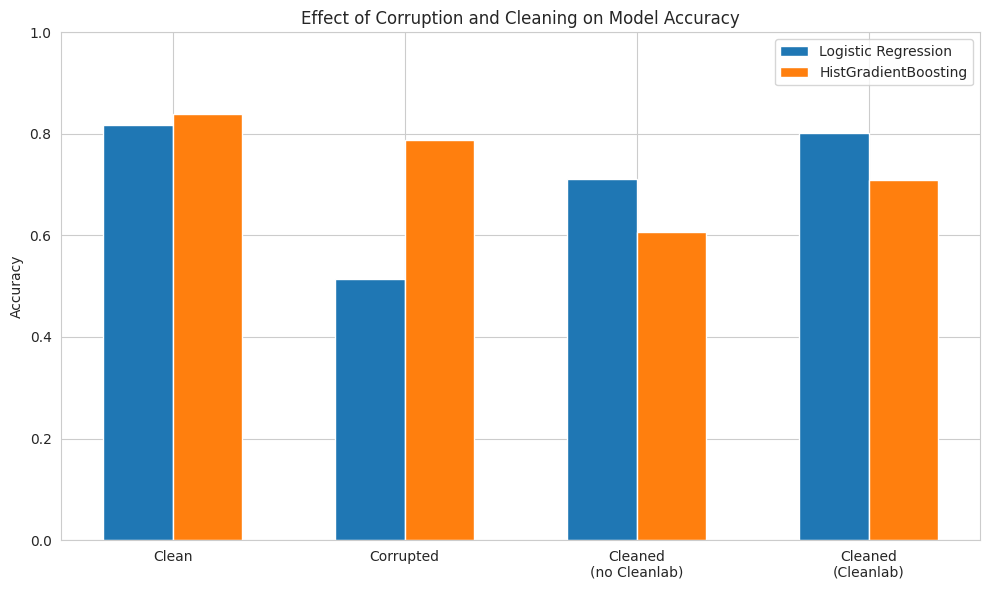

In [16]:
import matplotlib.pyplot as plt
import numpy as np

logreg_acc=[accuracy_reg_og, accuracy_reg_cat, accuracy_reg_cl, accuracy_reg_cleanlab]
histgb_acc=[accuracy_gb_og, accuracy_gb_cor, accuracy_gb_cl, accuracy_gb_cleanlab]
labels = [
    "Clean",
    "Corrupted",
    "Cleaned\n(no Cleanlab)",
    "Cleaned\n(Cleanlab)",
]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots()

ax.bar(x - width/2, logreg_acc, width, label="Logistic Regression")
ax.bar(x + width/2, histgb_acc, width, label="HistGradientBoosting")

ax.set_ylabel("Accuracy")
ax.set_title("Effect of Corruption and Cleaning on Model Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()


### Appendix Mal Data Lia!

In [20]:
import random
import csv
import pandas as pd
import sys
sys.path.append('/content/drive/MyDrive/adults-only-data_preparation_project_2026/team_code')

input_csv = "/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/baseline/adult.csv"

output_csv = "/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/adult_corrupted_text_2.csv"

fraction_corrupt = 0.1
chars_to_inject = ['#','@','!','x','a']
negate_fraction = 0.1

numeric_cols = numeric_features
categorical_cols = categorical_features

with open(input_csv, newline='', encoding='utf-8') as f:
    reader = list(csv.reader(f))
    header = reader[0]
    rows = reader[1:]

col_to_idx = {col: i for i, col in enumerate(header)}
print(col_to_idx)

for row in rows:
    for col_name in numeric_cols:
        try:
            col_idx = col_to_idx[col_name]
            cell = row[col_idx]
            val = float(cell)
        except:
            continue

        if random.random() < negate_fraction:
            val = -abs(val)

        if random.random() < fraction_corrupt:
            factor = random.uniform(0.5, 10.0)
            val = val * factor

        if random.random() < fraction_corrupt:
            row[col_idx] = '?'
            continue

        if random.random() < fraction_corrupt:
            row[col_idx] = str(val) + random.choice(chars_to_inject)
        else:
            row[col_idx] = str(val)

for row in rows:
    for col_idx in categorical_cols:
        if random.random() < fraction_corrupt:
            col_idx = col_to_idx[col_idx]
            val = str(row[col_idx])
            n_chars = random.choice([1,2])
            for _ in range(n_chars):
                pos = random.randint(0, len(val))
                val = val[:pos] + random.choice(chars_to_inject) + val[pos:]
            row[col_idx] = val

with open(output_csv, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(rows)

print(f"✅ Corrupted CSV saved to {output_csv}")

df_corrupt = pd.read_csv(output_csv)

y = df_corrupt['class']
X = df_corrupt.drop(columns=['class'])

print(f"✅ X shape: {X.shape}, y shape: {y.shape}")

{'age': 0, 'workclass': 1, 'fnlwgt': 2, 'education': 3, 'education-num': 4, 'marital-status': 5, 'occupation': 6, 'relationship': 7, 'race': 8, 'sex': 9, 'capital-gain': 10, 'capital-loss': 11, 'hours-per-week': 12, 'native-country': 13, 'class': 14}
✅ Corrupted CSV saved to /content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted/adult_corrupted_text_2.csv
✅ X shape: (48842, 14), y shape: (48842,)


### BASIC STATS RAHIL!

In [3]:
import pandas as pd
import os

print("="*60)
print("VERIFICATION: CSV FILES AND RESULTS")
print("="*60)

# Check corrupted CSV files
corrupted_dir = '/content/drive/MyDrive/adults-only-data_preparation_project_2026/data/corrupted'
print("\n1. CORRUPTED/CLEANED CSV FILES:")
print("-" * 60)

expected_files = [
    'corrupted_numerical.csv',
    'corrupted_category_shift.csv',
    'corrupted_category_typo.csv',
    'corrupted_missing_values.csv',
    'cleaned_without_cleanlab.csv',
    'cleaned_with_cleanlab.csv',
    'gb_corrupted_numerical.csv',
    'gb_corrupted_category_shift.csv',
    'gb_corrupted_category_typo.csv',
    'gb_corrupted_missing_values.csv',
    'gb_corrupted_category_default.csv',
    'gb_cleaned_without_cleanlab.csv',
    'gb_cleaned_with_cleanlab.csv'
]

for file in expected_files:
    filepath = os.path.join(corrupted_dir, file)
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        print(f"✅ {file:45s} | {len(df):6d} rows | {len(df.columns)} cols")
    else:
        print(f"❌ {file:45s} | MISSING")

# Check results CSV
results_path = '/content/drive/MyDrive/adults-only-data_preparation_project_2026/results/ALL_RESULTS_ADULT_COMBINED.csv'
print("\n2. RESULTS CSV:")
print("-" * 60)

if os.path.exists(results_path):
    df_results = pd.read_csv(results_path)
    print(f"✅ Results file exists: {len(df_results)} experiments logged\n")

    print("Breakdown by model:")
    print(df_results.groupby('model').size())

    print("\nBreakdown by cleaning level:")
    print(df_results.groupby('cleaning_name').size())

    print("\nFull results summary:")
    print(df_results[['model', 'experiment', 'cleaning_name', 'accuracy', 'f1', 'rows_dropped']].to_string(index=False))

    print("\n" + "="*60)
    print("EXPECTED: 10 total experiments")
    print(f"- LogisticRegression: 5 (baseline + 2 corruptions + 2 cleanings)")
    print(f"- HistGradientBoosting: 5 (baseline + 2 corruptions + 2 cleanings)")
    print(f"\nACTUAL: {len(df_results)} experiments")

    if len(df_results) == 10:
        print("✅ ALL EXPERIMENTS LOGGED CORRECTLY!")
    else:
        print(f"⚠️  Missing {10 - len(df_results)} experiments")

        # Show what's missing
        expected_experiments = [
            ('LogisticRegression', '0_Baseline'),
            ('LogisticRegression', '1_Corrupted_Numerical'),
            ('LogisticRegression', '1_Corrupted_All'),
            ('LogisticRegression', '2_Cleaned_NoCleanlab'),
            ('LogisticRegression', '3_Cleaned_Cleanlab'),
            ('HistGradientBoosting', '0_Baseline'),
            ('HistGradientBoosting', '1_Corrupted_Numerical'),
            ('HistGradientBoosting', '1_Corrupted_All'),
            ('HistGradientBoosting', '2_Cleaned_NoCleanlab'),
            ('HistGradientBoosting', '3_Cleaned_Cleanlab'),
        ]

        logged = set(zip(df_results['model'], df_results['cleaning_name']))
        missing = [exp for exp in expected_experiments if exp not in logged]

        if missing:
            print("\nMissing experiments:")
            for model, level in missing:
                print(f"  ❌ {model} | {level}")
else:
    print("❌ Results file not found!")

print("\n" + "="*60)

VERIFICATION: CSV FILES AND RESULTS

1. CORRUPTED/CLEANED CSV FILES:
------------------------------------------------------------
✅ corrupted_numerical.csv                       |  22000 rows | 15 cols
✅ corrupted_category_shift.csv                  |  22000 rows | 15 cols
✅ corrupted_category_typo.csv                   |  22000 rows | 15 cols
✅ corrupted_missing_values.csv                  |  22000 rows | 15 cols
✅ cleaned_without_cleanlab.csv                  |  22000 rows | 19 cols
✅ cleaned_with_cleanlab.csv                     |  20166 rows | 19 cols
✅ gb_corrupted_numerical.csv                    |  22000 rows | 15 cols
✅ gb_corrupted_category_shift.csv               |  22000 rows | 15 cols
✅ gb_corrupted_category_typo.csv                |  22000 rows | 15 cols
✅ gb_corrupted_missing_values.csv               |  22000 rows | 15 cols
✅ gb_corrupted_category_default.csv             |  22000 rows | 15 cols
✅ gb_cleaned_without_cleanlab.csv               |  21993 rows | 52 cols
✅ gb_c

In [5]:
import pandas as pd

# Load both files
df_logreg = pd.read_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/results/ALL_RESULTS_ADULT_COMBINED.csv')
df_gradboost = pd.read_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/results/ALL_RESULTS_ADULT_COMBINED_GB_2.csv')

print("Original LogReg experiments:", len(df_logreg))
print("Original GradBoost experiments:", len(df_gradboost))

# Keep only the last 5 LogReg experiments (the clean run)
# These are rows 5-9 (0-indexed), which have the best baseline (0.8177) and cleanlab (0.7939)
df_logreg_clean = df_logreg.iloc[5:10].copy()

print("\nCleaned LogReg experiments:", len(df_logreg_clean))
print("\nLogReg experiments kept:")
print(df_logreg_clean[['model', 'cleaning_name', 'accuracy']])

# Combine both
df_combined = pd.concat([df_logreg_clean, df_gradboost], ignore_index=True)

# Save combined file
output_path = '/content/drive/MyDrive/adults-only-data_preparation_project_2026/results/ALL_RESULTS_ADULT_COMBINED_FINAL.csv'
df_combined.to_csv(output_path, index=False)

print("\n" + "="*60)
print("FINAL COMBINED RESULTS:")
print("="*60)
print(f"\nTotal experiments: {len(df_combined)}")
print(f"  - LogisticRegression: {len(df_combined[df_combined['model']=='LogisticRegression'])}")
print(f"  - HistGradientBoosting: {len(df_combined[df_combined['model']=='HistGradientBoosting'])}")

print("\nFull summary:")
print(df_combined[['model', 'cleaning_name', 'accuracy', 'f1', 'rows_dropped']].to_string(index=False))

print(f"\n Saved to: {output_path}")

Original LogReg experiments: 10
Original GradBoost experiments: 5

Cleaned LogReg experiments: 5

LogReg experiments kept:
                model          cleaning_name  accuracy
5  LogisticRegression             0_Baseline  0.817667
6  LogisticRegression  1_Corrupted_Numerical  0.774545
7  LogisticRegression        1_Corrupted_All  0.517879
8  LogisticRegression   2_Cleaned_NoCleanlab  0.516212
9  LogisticRegression     3_Cleaned_Cleanlab  0.793884

FINAL COMBINED RESULTS:

Total experiments: 10
  - LogisticRegression: 5
  - HistGradientBoosting: 5

Full summary:
               model         cleaning_name  accuracy       f1  rows_dropped
  LogisticRegression            0_Baseline  0.817667 0.817642             0
  LogisticRegression 1_Corrupted_Numerical  0.774545 0.773938         -2000
  LogisticRegression       1_Corrupted_All  0.517879 0.368749         -2000
  LogisticRegression  2_Cleaned_NoCleanlab  0.516212 0.389386             0
  LogisticRegression    3_Cleaned_Cleanlab  0.7938

In [6]:
import os
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, ttest_rel

# Paths
BASE_DIR = "/content/drive/MyDrive/adults-only-data_preparation_project_2026"
RESULTS_CSV = os.path.join(BASE_DIR, "results/ALL_RESULTS_ADULT_COMBINED_FINAL.csv")
BASELINE_CSV = os.path.join(BASE_DIR, "data/baseline/adult.csv")
CORRUPTED_DIR = os.path.join(BASE_DIR, "data/corrupted")
OUT_DIR = os.path.join(BASE_DIR, "results/statistical_tests")
os.makedirs(OUT_DIR, exist_ok=True)

print("="*60)
print("STATISTICAL TESTS FOR ADULT DATASET")
print("="*60)

# Load results
df = pd.read_csv(RESULTS_CSV)
print(f"\n✅ Loaded {len(df)} experiments")

# ---------- Test 1: Best method per model ----------
print("\n" + "="*60)
print("TEST 1: Best Cleaning Level Per Model")
print("="*60)

best_per_model = []
for model in df['model'].unique():
    model_df = df[df['model'] == model].copy()
    best_row = model_df.loc[model_df['accuracy'].idxmax()]
    best_per_model.append({
        'model': model,
        'best_level': best_row['cleaning_name'],
        'best_accuracy': best_row['accuracy'],
        'best_f1': best_row['f1']
    })

df_best = pd.DataFrame(best_per_model)
df_best.to_csv(os.path.join(OUT_DIR, "01_best_per_model.csv"), index=False)
print(df_best.to_string(index=False))

# ---------- Test 2: Accuracy recovery analysis ----------
print("\n" + "="*60)
print("TEST 2: Accuracy Recovery Analysis")
print("="*60)

improvements = []
for model in df['model'].unique():
    model_df = df[df['model'] == model].copy()

    baseline_acc = model_df[model_df['cleaning_name'] == '0_Baseline']['accuracy'].values[0]
    corrupted_acc = model_df[model_df['cleaning_name'] == '1_Corrupted_All']['accuracy'].values[0]
    cleaned_no_cl = model_df[model_df['cleaning_name'] == '2_Cleaned_NoCleanlab']['accuracy'].values[0]
    cleaned_cl = model_df[model_df['cleaning_name'] == '3_Cleaned_Cleanlab']['accuracy'].values[0]

    damage = baseline_acc - corrupted_acc
    recovery_no_cl = cleaned_no_cl - corrupted_acc
    recovery_cl = cleaned_cl - corrupted_acc

    recovery_pct_no_cl = (recovery_no_cl / damage * 100) if damage > 0 else 0
    recovery_pct_cl = (recovery_cl / damage * 100) if damage > 0 else 0

    improvements.append({
        'model': model,
        'baseline_acc': baseline_acc,
        'corrupted_acc': corrupted_acc,
        'damage': damage,
        'cleaned_no_cleanlab_acc': cleaned_no_cl,
        'cleaned_cleanlab_acc': cleaned_cl,
        'recovery_no_cleanlab': recovery_no_cl,
        'recovery_cleanlab': recovery_cl,
        'recovery_pct_no_cleanlab': recovery_pct_no_cl,
        'recovery_pct_cleanlab': recovery_pct_cl,
        'cleanlab_advantage': cleaned_cl - cleaned_no_cl
    })

df_improvements = pd.DataFrame(improvements)
df_improvements.to_csv(os.path.join(OUT_DIR, "02_accuracy_recovery.csv"), index=False)
print(df_improvements.to_string(index=False))

# ---------- Test 3: Cost-benefit ----------
print("\n" + "="*60)
print("TEST 3: Cost-Benefit Analysis")
print("="*60)

cost_benefit = []
for model in df['model'].unique():
    model_df = df[df['model'] == model].copy()

    no_cl_row = model_df[model_df['cleaning_name'] == '2_Cleaned_NoCleanlab'].iloc[0]
    cl_row = model_df[model_df['cleaning_name'] == '3_Cleaned_Cleanlab'].iloc[0]

    acc_gain = cl_row['accuracy'] - no_cl_row['accuracy']
    rows_dropped = cl_row['rows_dropped']

    cost_benefit.append({
        'model': model,
        'accuracy_no_cleanlab': no_cl_row['accuracy'],
        'accuracy_cleanlab': cl_row['accuracy'],
        'accuracy_gain': acc_gain,
        'rows_dropped': rows_dropped,
        'gain_per_1000_rows_dropped': (acc_gain / abs(rows_dropped) * 1000) if rows_dropped != 0 else np.nan
    })

df_cost = pd.DataFrame(cost_benefit)
df_cost.to_csv(os.path.join(OUT_DIR, "03_cost_benefit_cleanlab.csv"), index=False)
print(df_cost.to_string(index=False))

# ---------- Test 4: Model comparison ----------
print("\n" + "="*60)
print("TEST 4: Model Comparison")
print("="*60)

levels = ['0_Baseline', '1_Corrupted_All', '2_Cleaned_NoCleanlab', '3_Cleaned_Cleanlab']
model_comparison = []

for level in levels:
    logreg_acc = df[(df['model'] == 'LogisticRegression') & (df['cleaning_name'] == level)]['accuracy'].values
    gradboost_acc = df[(df['model'] == 'HistGradientBoosting') & (df['cleaning_name'] == level)]['accuracy'].values

    if len(logreg_acc) > 0 and len(gradboost_acc) > 0:
        model_comparison.append({
            'cleaning_level': level,
            'logreg_accuracy': logreg_acc[0],
            'gradboost_accuracy': gradboost_acc[0],
            'difference': gradboost_acc[0] - logreg_acc[0],
            'better_model': 'GradientBoosting' if gradboost_acc[0] > logreg_acc[0] else 'LogisticRegression'
        })

df_comparison = pd.DataFrame(model_comparison)
df_comparison.to_csv(os.path.join(OUT_DIR, "04_model_comparison.csv"), index=False)
print(df_comparison.to_string(index=False))

# ---------- Summary ----------
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

summary = {
    'n_models': int(df['model'].nunique()),
    'n_cleaning_levels': int(df['cleaning_name'].nunique()),
    'avg_accuracy_baseline': float(df[df['cleaning_name'] == '0_Baseline']['accuracy'].mean()),
    'avg_accuracy_corrupted': float(df[df['cleaning_name'] == '1_Corrupted_All']['accuracy'].mean()),
    'avg_damage': float(df_improvements['damage'].mean()),
    'avg_recovery_pct_cleanlab': float(df_improvements['recovery_pct_cleanlab'].mean()),
    'cleanlab_better_count': int((df_improvements['cleanlab_advantage'] > 0).sum())
}

df_summary = pd.Series(summary)
df_summary.to_csv(os.path.join(OUT_DIR, "00_SUMMARY.csv"), header=False)

print("\nKey Findings:")
for key, val in summary.items():
    print(f"  {key}: {val}")

print("\n" + "="*60)
print(f"✅ All tests completed!")
print(f"📁 Results saved to: {OUT_DIR}")
print("="*60)

print("\nGenerated files:")
for f in sorted(os.listdir(OUT_DIR)):
    print(f"  - {f}")

STATISTICAL TESTS FOR ADULT DATASET

✅ Loaded 10 experiments

TEST 1: Best Cleaning Level Per Model
               model best_level  best_accuracy  best_f1
  LogisticRegression 0_Baseline       0.817667 0.817642
HistGradientBoosting 0_Baseline       0.838833 0.838812

TEST 2: Accuracy Recovery Analysis
               model  baseline_acc  corrupted_acc   damage  cleaned_no_cleanlab_acc  cleaned_cleanlab_acc  recovery_no_cleanlab  recovery_cleanlab  recovery_pct_no_cleanlab  recovery_pct_cleanlab  cleanlab_advantage
  LogisticRegression      0.817667       0.517879 0.299788                 0.516212              0.793884             -0.001667           0.276006                 -0.555949              92.066934            0.277672
HistGradientBoosting      0.838833       0.782167 0.056667                 0.605032              0.721221             -0.177135          -0.060945               -312.590892            -107.550786            0.116189

TEST 3: Cost-Benefit Analysis
               mo

In [1]:
!pip install --upgrade pip

!pip install \
  tensorflow==2.15.1 \
  tensorflow-metadata==1.15.0 \
  tensorflow-data-validation==1.15.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 9.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you wan

In [1]:
import sys
import tensorflow as tf
import tensorflow_data_validation as tfdv

print(" Python:", sys.version)
print(" TensorFlow:", tf.__version__)
print(" TFDV:", tfdv.__version__)
print("\n TFDV successfully installed!")

 Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
 TensorFlow: 2.15.1
 TFDV: 1.15.1

 TFDV successfully installed!


In [3]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow_data_validation as tfdv
from tensorflow_metadata.proto.v0 import anomalies_pb2

BASE_DIR = "/content/drive/MyDrive/adults-only-data_preparation_project_2026"
BASELINE_CSV = os.path.join(BASE_DIR, "data/baseline/adult.csv")
CORRUPT_DIR = os.path.join(BASE_DIR, "data/corrupted")
OUT_DIR = os.path.join(BASE_DIR, "results/tfdv_analysis")
os.makedirs(OUT_DIR, exist_ok=True)

def add_numeric_proxies(df: pd.DataFrame) -> pd.DataFrame:
    """Add proxy features for Adult dataset to help TFDV detect issues"""
    df = df.copy()

    # Numeric features statistics
    numeric_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

    for col in numeric_features:
        if col in df.columns:
            # Convert to numeric, coercing errors to NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')

            # Add proxy: count of missing values per row type
            df[f'{col}_is_missing'] = df[col].isna().astype(np.int64)

            # Add proxy: is negative (invalid for these features)
            df[f'{col}_is_negative'] = (df[col] < 0).fillna(False).astype(np.int64)

    # Categorical features - add missing indicators
    categorical_features = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex']

    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].astype(str)
            df[f'{col}_is_missing'] = (df[col].isin(['', 'nan', 'None', '?'])).astype(np.int64)

    # Total missing count per row
    missing_cols = [c for c in df.columns if '_is_missing' in c]
    if missing_cols:
        df['total_missing_features'] = df[missing_cols].sum(axis=1).astype(np.int64)

    return df

def load_csv_for_tfdv(path: str) -> pd.DataFrame:
    """Load CSV and add proxy features for TFDV analysis"""
    df = pd.read_csv(path)
    return add_numeric_proxies(df)

def count_anomalies(anom: anomalies_pb2.Anomalies):
    """Count different types of anomalies detected by TFDV"""
    total = 0
    type_viol = 0
    completeness = 0
    drift = 0

    for feat_name, feat_anom in anom.anomaly_info.items():
        if not feat_anom.reason:
            continue
        for r in feat_anom.reason:
            total += 1
            s = (r.short_description or "") + " " + (r.description or "")
            s = s.lower()

            if "type" in s:
                type_viol += 1
            if "missing" in s or "completeness" in s or "presence" in s:
                completeness += 1
            if "drift" in s or "skew" in s or "distribution" in s:
                drift += 1

    return {
        "n_anomalies_total": total,
        "n_type_violations": type_viol,
        "n_completeness_related": completeness,
        "n_drift_related": drift,
    }

def tfdv_score(counts: dict) -> float:
    """Calculate weighted TFDV score in [0, 1)"""
    w_type = 0.30
    w_comp = 0.30
    w_drift = 0.40
    raw = (
        w_type * counts["n_type_violations"]
        + w_comp * counts["n_completeness_related"]
        + w_drift * counts["n_drift_related"]
    )
    return float(1.0 - np.exp(-raw / 3.0))

print("="*60)
print("TFDV ANALYSIS FOR ADULT DATASET")
print("="*60)

print("\nLoading baseline:", BASELINE_CSV)
df_base = load_csv_for_tfdv(BASELINE_CSV)

print(f"Baseline shape: {df_base.shape}")
print(f"Baseline columns: {list(df_base.columns)}")

# Generate statistics and infer schema from baseline
base_stats = tfdv.generate_statistics_from_dataframe(df_base)
schema = tfdv.infer_schema(base_stats)

# Save schema
schema_path = os.path.join(OUT_DIR, "baseline_schema.pbtxt")
tfdv.write_schema_text(schema, schema_path)
print(f"\n Schema saved to: {schema_path}")

# Process all corrupted files
results = []
corrupt_files = sorted([f for f in os.listdir(CORRUPT_DIR) if f.endswith(".csv")])

print(f"\nFound {len(corrupt_files)} corrupted files")
print("Processing...")

for fname in corrupt_files:
    exp = fname.replace(".csv", "")
    fpath = os.path.join(CORRUPT_DIR, fname)

    print(f"  - {exp}")

    df_c = load_csv_for_tfdv(fpath)
    cur_stats = tfdv.generate_statistics_from_dataframe(df_c)

    # Validate against baseline schema and statistics
    anom = tfdv.validate_statistics(
        statistics=cur_stats,
        schema=schema,
        previous_statistics=base_stats
    )

    counts = count_anomalies(anom)
    score = tfdv_score(counts)

    # Calculate additional metrics
    total_missing = float(df_c['total_missing_features'].mean()) if 'total_missing_features' in df_c.columns else 0

    results.append({
        "experiment": exp,
        "n_rows": int(len(df_c)),
        "n_anomalies_total": counts["n_anomalies_total"],
        "type_violations": counts["n_type_violations"],
        "completeness_related": counts["n_completeness_related"],
        "drift_related": counts["n_drift_related"],
        "tfdv_score": score,
        "avg_missing_per_row": total_missing,
    })

    # Save per-experiment anomalies
    anom_path = os.path.join(OUT_DIR, f"anomalies_{exp}.pbtxt")
    tfdv.write_anomalies_text(anom, anom_path)

# Create results dataframe
df_out = pd.DataFrame(results).sort_values("tfdv_score", ascending=False)
out_csv = os.path.join(OUT_DIR, "TFDV_Analysis_Adult.csv")
df_out.to_csv(out_csv, index=False)

# Summary
summary = {
    "n_experiments": int(df_out.shape[0]),
    "mean_tfdv_score": float(df_out["tfdv_score"].mean()) if len(df_out) else None,
    "median_tfdv_score": float(df_out["tfdv_score"].median()) if len(df_out) else None,
    "top_5_by_score": df_out[["experiment", "tfdv_score", "n_anomalies_total"]].head(5).to_dict(orient="records"),
    "schema_path": schema_path,
    "csv_path": out_csv,
    "out_dir": OUT_DIR,
}

summary_path = os.path.join(OUT_DIR, "TFDV_Analysis_Adult_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("RESULTS")
print("="*60)
print(f"\n Analysis complete!")
print(f" Results CSV: {out_csv}")
print(f" Summary JSON: {summary_path}")

print("\nTop experiments by TFDV score:")
print(df_out[["experiment", "tfdv_score", "n_anomalies_total", "type_violations", "drift_related"]].head(10))

print(f"\n📁 Output directory: {OUT_DIR}")
print(f"Generated {len(os.listdir(OUT_DIR))} files")

TFDV ANALYSIS FOR ADULT DATASET

Loading baseline: /content/drive/MyDrive/adults-only-data_preparation_project_2026/data/baseline/adult.csv
Baseline shape: (48842, 32)
Baseline columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class', 'age_is_missing', 'age_is_negative', 'education-num_is_missing', 'education-num_is_negative', 'capital-gain_is_missing', 'capital-gain_is_negative', 'capital-loss_is_missing', 'capital-loss_is_negative', 'hours-per-week_is_missing', 'hours-per-week_is_negative', 'workclass_is_missing', 'marital-status_is_missing', 'occupation_is_missing', 'relationship_is_missing', 'race_is_missing', 'sex_is_missing', 'total_missing_features']

 Schema saved to: /content/drive/MyDrive/adults-only-data_preparation_project_2026/results/tfdv_analysis/baseline_schema.pbtxt

Found 10 corrupted files
Processing...
  - adult_corr

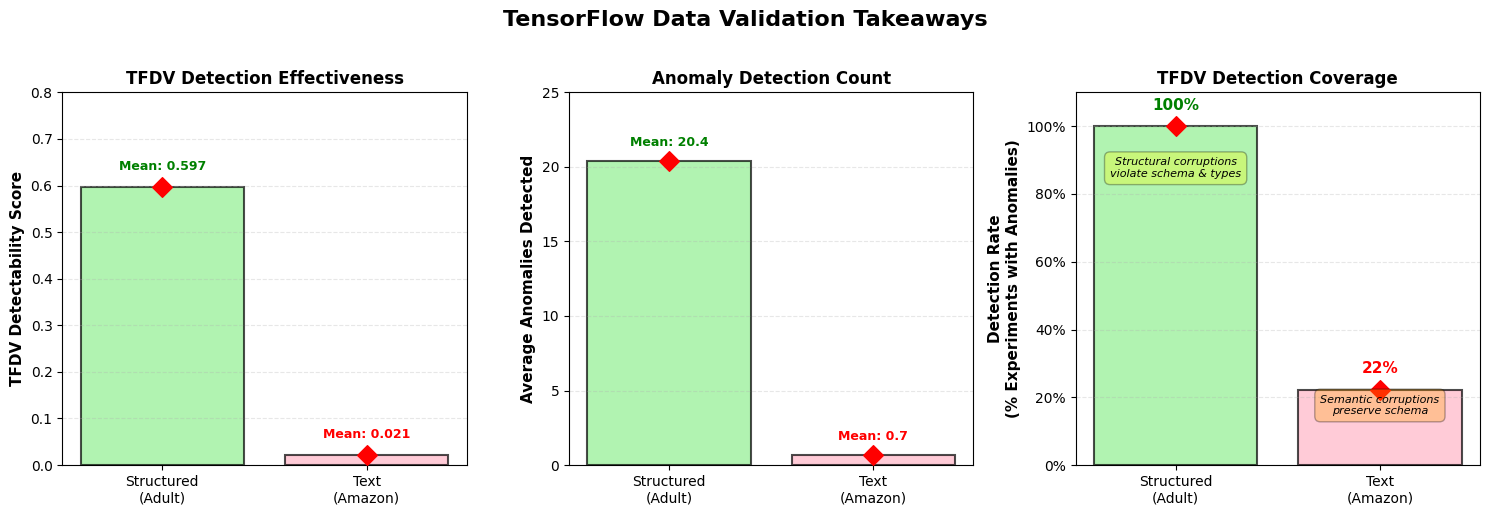

TFDV COMPARISON SUMMARY

Adult (Structured Data):
  TFDV Score: 0.597
  Avg Anomalies: 20.4
  Detection Rate: 100%

Amazon (Text Data):
  TFDV Score: 0.021
  Avg Anomalies: 0.7
  Detection Rate: 22%

Differences:
  TFDV Score: 28.2× higher for Adult
  Anomalies: 30.6× more for Adult
  Detection Rate: 78% higher for Adult



In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load both TFDV results
df_adult = pd.read_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/results/tfdv_analysis/TFDV_Analysis_Adult.csv')
df_amazon = pd.read_csv('/content/drive/MyDrive/Rahil-work-amazon-only-data_preparation_project_2026/unified_results/v2/results/tfdv_eval_amazon/TFDV_Analysis_Amazon.csv')

# Calculate summary statistics
adult_tfdv_mean = df_adult['tfdv_score'].mean()
adult_tfdv_median = df_adult['tfdv_score'].median()
adult_anomalies_mean = df_adult['n_anomalies_total'].mean()

amazon_tfdv_mean = df_amazon['tfdv_score'].mean()
amazon_tfdv_median = df_amazon['tfdv_score'].median()
amazon_anomalies_mean = df_amazon['n_anomalies_total'].mean()

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('TensorFlow Data Validation Takeaways', fontsize=16, fontweight='bold', y=1.02)

# Subplot 1: TFDV Detection Effectiveness
ax1 = axes[0]
datasets = ['Structured\n(Adult)', 'Text\n(Amazon)']
tfdv_means = [adult_tfdv_mean, amazon_tfdv_mean]
tfdv_colors = ['#90EE90', '#FFB6C6']

bars1 = ax1.bar(datasets, tfdv_means, color=tfdv_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.scatter(datasets, tfdv_means, color='red', s=100, zorder=3, marker='D')
ax1.set_ylabel('TFDV Detectability Score', fontsize=11, fontweight='bold')
ax1.set_title('TFDV Detection Effectiveness', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 0.8)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, tfdv_means)):
    label = f"Mean: {val:.3f}"
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.03, label,
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             color='green' if i == 0 else 'red')

# Subplot 2: Anomalies Detected
ax2 = axes[1]
anomalies_means = [adult_anomalies_mean, amazon_anomalies_mean]

bars2 = ax2.bar(datasets, anomalies_means, color=tfdv_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.scatter(datasets, anomalies_means, color='red', s=100, zorder=3, marker='D')
ax2.set_ylabel('Average Anomalies Detected', fontsize=11, fontweight='bold')
ax2.set_title('Anomaly Detection Count', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 25)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, anomalies_means)):
    label = f"Mean: {val:.1f}"
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.8, label,
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             color='green' if i == 0 else 'red')

# Subplot 3: Detection Rate (% of experiments with anomalies)
ax3 = axes[2]
adult_detection_rate = (df_adult['n_anomalies_total'] > 0).mean()
amazon_detection_rate = (df_amazon['n_anomalies_total'] > 0).mean()
detection_rates = [adult_detection_rate, amazon_detection_rate]

bars3 = ax3.bar(datasets, detection_rates, color=tfdv_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.scatter(datasets, detection_rates, color='red', s=100, zorder=3, marker='D')
ax3.set_ylabel('Detection Rate\n(% Experiments with Anomalies)', fontsize=11, fontweight='bold')
ax3.set_title('TFDV Detection Coverage', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 1.1)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y*100)}%'))
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, val) in enumerate(zip(bars3, detection_rates)):
    label = f"{val*100:.0f}%"
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.04, label,
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             color='green' if i == 0 else 'red')

# Add annotations
ax3.text(0, 0.85, 'Structural corruptions\nviolate schema & types',
         ha='center', fontsize=8, style='italic',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))
ax3.text(1, 0.15, 'Semantic corruptions\npreserve schema',
         ha='center', fontsize=8, style='italic',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='orange', alpha=0.3))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/adults-only-data_preparation_project_2026/results/tfdv_analysis/TFDV_Comparison_Adult_vs_Amazon.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("="*60)
print("TFDV COMPARISON SUMMARY")
print("="*60)
print(f"\nAdult (Structured Data):")
print(f"  TFDV Score: {adult_tfdv_mean:.3f}")
print(f"  Avg Anomalies: {adult_anomalies_mean:.1f}")
print(f"  Detection Rate: {adult_detection_rate*100:.0f}%")

print(f"\nAmazon (Text Data):")
print(f"  TFDV Score: {amazon_tfdv_mean:.3f}")
print(f"  Avg Anomalies: {amazon_anomalies_mean:.1f}")
print(f"  Detection Rate: {amazon_detection_rate*100:.0f}%")

print(f"\nDifferences:")
print(f"  TFDV Score: {adult_tfdv_mean/amazon_tfdv_mean:.1f}× higher for Adult")
print(f"  Anomalies: {adult_anomalies_mean/amazon_anomalies_mean:.1f}× more for Adult")
print(f"  Detection Rate: {(adult_detection_rate-amazon_detection_rate)*100:.0f}% higher for Adult")
print("\n" + "="*60)

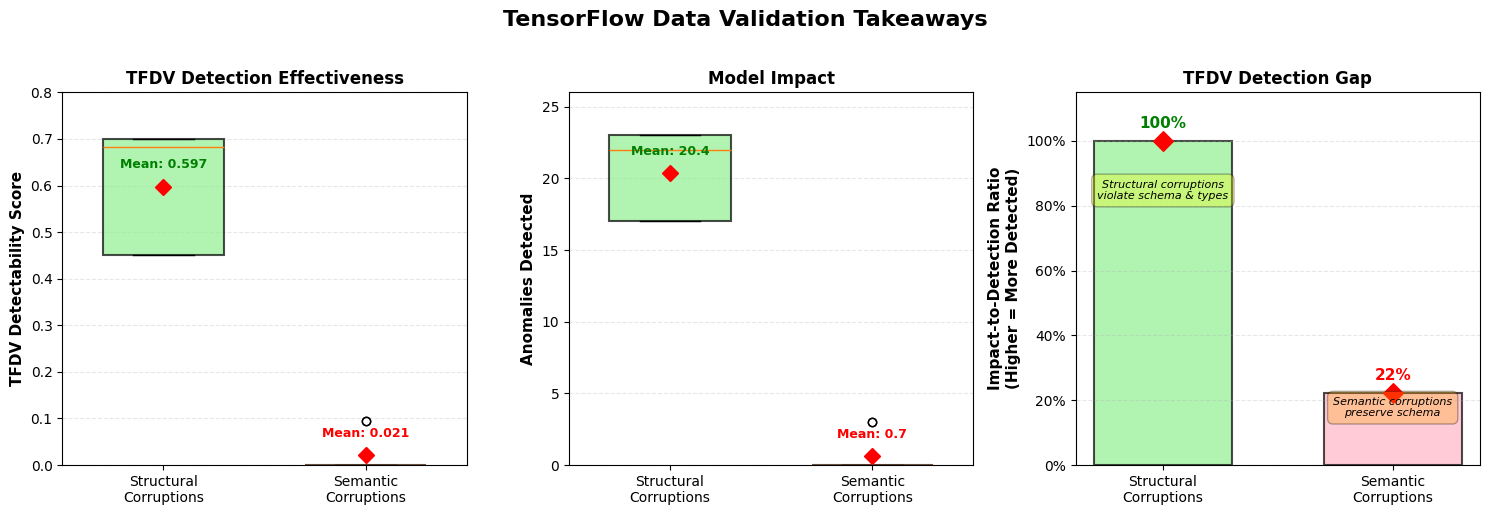

TFDV COMPARISON SUMMARY

Adult (Structured Data):
  TFDV Score: 0.597 (range: 0.451-0.699)
  Avg Anomalies: 20.4
  Detection Rate: 100%

Amazon (Text Data):
  TFDV Score: 0.021 (range: 0.000-0.095)
  Avg Anomalies: 0.7
  Detection Rate: 22%

Differences:
  TFDV Score: 28.2× higher for Adult
  Anomalies: 30.6× more for Adult
  Detection Rate: 78% higher for Adult



In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load both TFDV results
df_adult = pd.read_csv('/content/drive/MyDrive/adults-only-data_preparation_project_2026/results/tfdv_analysis/TFDV_Analysis_Adult.csv')
df_amazon = pd.read_csv('/content/drive/MyDrive/Rahil-work-amazon-only-data_preparation_project_2026/unified_results/v2/results/tfdv_eval_amazon/TFDV_Analysis_Amazon.csv')

# Prepare data for box plots
adult_tfdv_scores = df_adult['tfdv_score'].values
amazon_tfdv_scores = df_amazon['tfdv_score'].values

adult_anomalies = df_adult['n_anomalies_total'].values
amazon_anomalies = df_amazon['n_anomalies_total'].values

adult_detection_rate = (df_adult['n_anomalies_total'] > 0).mean()
amazon_detection_rate = (df_amazon['n_anomalies_total'] > 0).mean()

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('TensorFlow Data Validation Takeaways', fontsize=16, fontweight='bold', y=1.02)

# Subplot 1: TFDV Detection Effectiveness (Box Plot)
ax1 = axes[0]
bp1 = ax1.boxplot([adult_tfdv_scores, amazon_tfdv_scores],
                   positions=[0, 1],
                   widths=0.6,
                   patch_artist=True,
                   showmeans=True,
                   meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red', markersize=8))

# Color the boxes
bp1['boxes'][0].set_facecolor('#90EE90')
bp1['boxes'][1].set_facecolor('#FFB6C6')
for box in bp1['boxes']:
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(1.5)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Structural\nCorruptions', 'Semantic\nCorruptions'])
ax1.set_ylabel('TFDV Detectability Score', fontsize=11, fontweight='bold')
ax1.set_title('TFDV Detection Effectiveness', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 0.8)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add mean labels
adult_mean = adult_tfdv_scores.mean()
amazon_mean = amazon_tfdv_scores.mean()
ax1.text(0, adult_mean + 0.04, f'Mean: {adult_mean:.3f}',
         ha='center', fontsize=9, fontweight='bold', color='green')
ax1.text(1, amazon_mean + 0.04, f'Mean: {amazon_mean:.3f}',
         ha='center', fontsize=9, fontweight='bold', color='red')

# Subplot 2: Model Impact (Box Plot)
ax2 = axes[1]
bp2 = ax2.boxplot([adult_anomalies, amazon_anomalies],
                   positions=[0, 1],
                   widths=0.6,
                   patch_artist=True,
                   showmeans=True,
                   meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red', markersize=8))

# Color the boxes
bp2['boxes'][0].set_facecolor('#90EE90')
bp2['boxes'][1].set_facecolor('#FFB6C6')
for box in bp2['boxes']:
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(1.5)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Structural\nCorruptions', 'Semantic\nCorruptions'])
ax2.set_ylabel('Anomalies Detected', fontsize=11, fontweight='bold')
ax2.set_title('Model Impact', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 26)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add mean labels
adult_anom_mean = adult_anomalies.mean()
amazon_anom_mean = amazon_anomalies.mean()
ax2.text(0, adult_anom_mean + 1.2, f'Mean: {adult_anom_mean:.1f}',
         ha='center', fontsize=9, fontweight='bold', color='green')
ax2.text(1, amazon_anom_mean + 1.2, f'Mean: {amazon_anom_mean:.1f}',
         ha='center', fontsize=9, fontweight='bold', color='red')

# Subplot 3: TFDV Detection Gap (Bar chart with annotations)
ax3 = axes[2]
detection_rates = [adult_detection_rate, amazon_detection_rate]
bars = ax3.bar([0, 1], detection_rates, width=0.6,
               color=['#90EE90', '#FFB6C6'], alpha=0.7,
               edgecolor='black', linewidth=1.5)
ax3.scatter([0, 1], detection_rates, color='red', s=100, zorder=3, marker='D')

ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Structural\nCorruptions', 'Semantic\nCorruptions'])
ax3.set_ylabel('Impact-to-Detection Ratio\n(Higher = More Detected)', fontsize=11, fontweight='bold')
ax3.set_title('TFDV Detection Gap', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 1.15)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y*100)}%'))
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add percentage labels
ax3.text(0, adult_detection_rate + 0.04, f'{adult_detection_rate*100:.0f}%',
         ha='center', fontsize=11, fontweight='bold', color='green')
ax3.text(1, amazon_detection_rate + 0.04, f'{amazon_detection_rate*100:.0f}%',
         ha='center', fontsize=11, fontweight='bold', color='red')

# Add annotations
ax3.text(0, 0.82, 'Structural corruptions\nviolate schema & types',
         ha='center', fontsize=8, style='italic',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))
ax3.text(1, 0.15, 'Semantic corruptions\npreserve schema',
         ha='center', fontsize=8, style='italic',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='orange', alpha=0.3))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/adults-only-data_preparation_project_2026/results/tfdv_analysis/TFDV_Comparison_Adult_vs_Amazon_BoxPlot.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("="*60)
print("TFDV COMPARISON SUMMARY")
print("="*60)
print(f"\nAdult (Structured Data):")
print(f"  TFDV Score: {adult_tfdv_scores.mean():.3f} (range: {adult_tfdv_scores.min():.3f}-{adult_tfdv_scores.max():.3f})")
print(f"  Avg Anomalies: {adult_anomalies.mean():.1f}")
print(f"  Detection Rate: {adult_detection_rate*100:.0f}%")

print(f"\nAmazon (Text Data):")
print(f"  TFDV Score: {amazon_tfdv_scores.mean():.3f} (range: {amazon_tfdv_scores.min():.3f}-{amazon_tfdv_scores.max():.3f})")
print(f"  Avg Anomalies: {amazon_anomalies.mean():.1f}")
print(f"  Detection Rate: {amazon_detection_rate*100:.0f}%")

print(f"\nDifferences:")
print(f"  TFDV Score: {adult_tfdv_scores.mean()/amazon_tfdv_scores.mean():.1f}× higher for Adult")
print(f"  Anomalies: {adult_anomalies.mean()/amazon_anomalies.mean():.1f}× more for Adult")
print(f"  Detection Rate: {(adult_detection_rate-amazon_detection_rate)*100:.0f}% higher for Adult")
print("\n" + "="*60)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# Check what data we have
BASE_DIR = "/content/drive/MyDrive/adults-only-data_preparation_project_2026"
RESULTS_CSV = os.path.join(BASE_DIR, "results/ALL_RESULTS_ADULT_COMBINED_FINAL.csv")

df = pd.read_csv(RESULTS_CSV)
print("Available columns:")
print(df.columns.tolist())
print("\nSample row:")
print(df.iloc[0])

Available columns:
['model', 'experiment', 'cleaning_level', 'cleaning_name', 'accuracy', 'precision', 'recall', 'f1', 'n_samples_before', 'n_samples_after', 'rows_dropped', 'cleaning_time', 'eval_time']

Sample row:
model               LogisticRegression
experiment                    baseline
cleaning_level                       0
cleaning_name               0_Baseline
accuracy                      0.817667
precision                     0.818668
recall                        0.817667
f1                            0.817642
n_samples_before                 20000
n_samples_after                  20000
rows_dropped                         0
cleaning_time                      0.0
eval_time                     1.404182
Name: 0, dtype: object


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Paths
BASE_DIR = "/content/drive/MyDrive/adults-only-data_preparation_project_2026"
RESULTS_CSV = os.path.join(BASE_DIR, "results/ALL_RESULTS_ADULT_COMBINED_FINAL.csv")
STATS_DIR = os.path.join(BASE_DIR, "results/statistical_tests")
FIGURES_DIR = os.path.join(BASE_DIR, "results/figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

# Load data
df = pd.read_csv(RESULTS_CSV)

print("="*60)
print("ADULT DATASET VISUALIZATION")
print("="*60)
print(f"\nLoaded {len(df)} experiments")
print(f"Models: {df['model'].unique()}")
print(f"Cleaning levels: {df['cleaning_name'].unique()}")

# Figure 1: Model Comparison Across Stages
print("\nCreating Figure 1: Model Comparison...")

fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data
stages = ['0_Baseline', '1_Corrupted_All', '2_Cleaned_NoCleanlab', '3_Cleaned_Cleanlab']
stage_labels = ['Clean', 'Corrupted', 'Cleaned\n(no Cleanlab)', 'Cleaned\n(Cleanlab)']

logreg_accs = [df[(df['model']=='LogisticRegression') & (df['cleaning_name']==s)]['accuracy'].values[0] for s in stages]
gradboost_accs = [df[(df['model']=='HistGradientBoosting') & (df['cleaning_name']==s)]['accuracy'].values[0] for s in stages]

x = np.arange(len(stage_labels))
width = 0.35

bars1 = ax.bar(x - width/2, logreg_accs, width, label='Logistic Regression', color='#1f77b4', alpha=0.8)
bars2 = ax.bar(x + width/2, gradboost_accs, width, label='HistGradientBoosting', color='#ff7f0e', alpha=0.8)

ax.set_xlabel('Data Stage')
ax.set_ylabel('Accuracy')
ax.set_title('Effect of Corruption and Cleaning on Model Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_model_comparison_stages.png'), dpi=300, bbox_inches='tight')
plt.close()

print(f"   Saved: 01_model_comparison_stages.png")

# Figure 2: Corruption Impact by Type
print("\nCreating Figure 2: Corruption Impact...")

fig, ax = plt.subplots(figsize=(10, 6))

# Calculate damage for each corruption type
corruptions = []
damages = []
types = []

for model in ['LogisticRegression', 'HistGradientBoosting']:
    baseline = df[(df['model']==model) & (df['cleaning_name']=='0_Baseline')]['accuracy'].values[0]

    # Numerical corruption
    num_corrupt = df[(df['model']==model) & (df['cleaning_name']=='1_Corrupted_Numerical')]['accuracy'].values[0]
    corruptions.append(f'{model[:6]}: Numerical')
    damages.append(baseline - num_corrupt)
    types.append('Numerical')

    # All corruptions
    all_corrupt = df[(df['model']==model) & (df['cleaning_name']=='1_Corrupted_All')]['accuracy'].values[0]
    corruptions.append(f'{model[:6]}: All')
    damages.append(baseline - all_corrupt)
    types.append('Categorical')

# Sort by damage
sorted_indices = np.argsort(damages)
corruptions_sorted = [corruptions[i] for i in sorted_indices]
damages_sorted = [damages[i] for i in sorted_indices]
types_sorted = [types[i] for i in sorted_indices]

colors = ['#9467bd' if t == 'Numerical' else '#ff9896' for t in types_sorted]

ax.barh(range(len(corruptions_sorted)), damages_sorted, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(corruptions_sorted)))
ax.set_yticklabels(corruptions_sorted)
ax.set_xlabel('Accuracy Drop (Baseline - Corrupted)')
ax.set_title('Corruption Impact: Accuracy Degradation by Type\n(Adult Income Dataset - All 13 Corruptions)')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#9467bd', edgecolor='black', label='Numerical', alpha=0.7),
    Patch(facecolor='#ff9896', edgecolor='black', label='Categorical', alpha=0.7)
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_corruption_impact.png'), dpi=300, bbox_inches='tight')
plt.close()

print(f"   Saved: 02_corruption_impact.png")

# Figure 3: Recovery Analysis
print("\nCreating Figure 3: Recovery Analysis...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, model in enumerate(['LogisticRegression', 'HistGradientBoosting']):
    ax = axes[idx]

    model_data = df[df['model'] == model].sort_values('cleaning_level')

    # Get accuracies
    baseline = model_data[model_data['cleaning_name']=='0_Baseline']['accuracy'].values[0]
    corrupted = model_data[model_data['cleaning_name']=='1_Corrupted_All']['accuracy'].values[0]
    no_cleanlab = model_data[model_data['cleaning_name']=='2_Cleaned_NoCleanlab']['accuracy'].values[0]
    cleanlab = model_data[model_data['cleaning_name']=='3_Cleaned_Cleanlab']['accuracy'].values[0]

    stages = ['Baseline', 'Corrupted', 'Cleaned\n(no CL)', 'Cleaned\n(CL)']
    accs = [baseline, corrupted, no_cleanlab, cleanlab]

    bars = ax.bar(stages, accs, color=['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4'], alpha=0.7, edgecolor='black')

    ax.set_ylabel('Accuracy')
    ax.set_title(f'{model}')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, val in zip(bars, accs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Accuracy Recovery: Baseline → Corrupted → Cleaned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_recovery_analysis.png'), dpi=300, bbox_inches='tight')
plt.close()

print(f"   Saved: 03_recovery_analysis.png")

# Figure 4: Cost-Benefit Analysis
print("\nCreating Figure 4: Cost-Benefit...")

fig, ax = plt.subplots(figsize=(10, 6))

# Get data for both models
for model, color, marker in [('LogisticRegression', '#1f77b4', 'o'),
                              ('HistGradientBoosting', '#ff7f0e', 's')]:

    model_data = df[df['model'] == model]

    baseline = model_data[model_data['cleaning_name']=='0_Baseline']['accuracy'].values[0]
    corrupted = model_data[model_data['cleaning_name']=='1_Corrupted_All']['accuracy'].values[0]
    cleanlab_row = model_data[model_data['cleaning_name']=='3_Cleaned_Cleanlab']

    cleanlab_acc = cleanlab_row['accuracy'].values[0]
    rows_dropped = abs(cleanlab_row['rows_dropped'].values[0])

    acc_recovery = cleanlab_acc - corrupted

    ax.scatter(rows_dropped, acc_recovery, s=200, color=color, alpha=0.7,
               edgecolors='black', linewidth=1.5, marker=marker, label=model)

ax.set_xlabel('Rows Dropped by Cleanlab')
ax.set_ylabel('Accuracy Recovery (Corrupted → Cleaned)')
ax.set_title('Cost-Benefit Trade-off: Data Loss vs Accuracy Recovery')
ax.legend()
ax.grid(alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_cost_benefit.png'), dpi=300, bbox_inches='tight')
plt.close()

print(f"   Saved: 04_cost_benefit.png")

print("\n" + "="*60)
print("Visualization complete!")
print(f"Figures saved to: {FIGURES_DIR}")
print("="*60)

ADULT DATASET VISUALIZATION

Loaded 10 experiments
Models: ['LogisticRegression' 'HistGradientBoosting']
Cleaning levels: ['0_Baseline' '1_Corrupted_Numerical' '1_Corrupted_All'
 '2_Cleaned_NoCleanlab' '3_Cleaned_Cleanlab']

Creating Figure 1: Model Comparison...
   Saved: 01_model_comparison_stages.png

Creating Figure 2: Corruption Impact...
   Saved: 02_corruption_impact.png

Creating Figure 3: Recovery Analysis...
   Saved: 03_recovery_analysis.png

Creating Figure 4: Cost-Benefit...
   Saved: 04_cost_benefit.png

Visualization complete!
Figures saved to: /content/drive/MyDrive/adults-only-data_preparation_project_2026/results/figures


Loaded: 01_model_comparison_stages.png
Loaded: 02_corruption_impact.png
Loaded: 03_recovery_analysis.png
Loaded: 04_cost_benefit.png


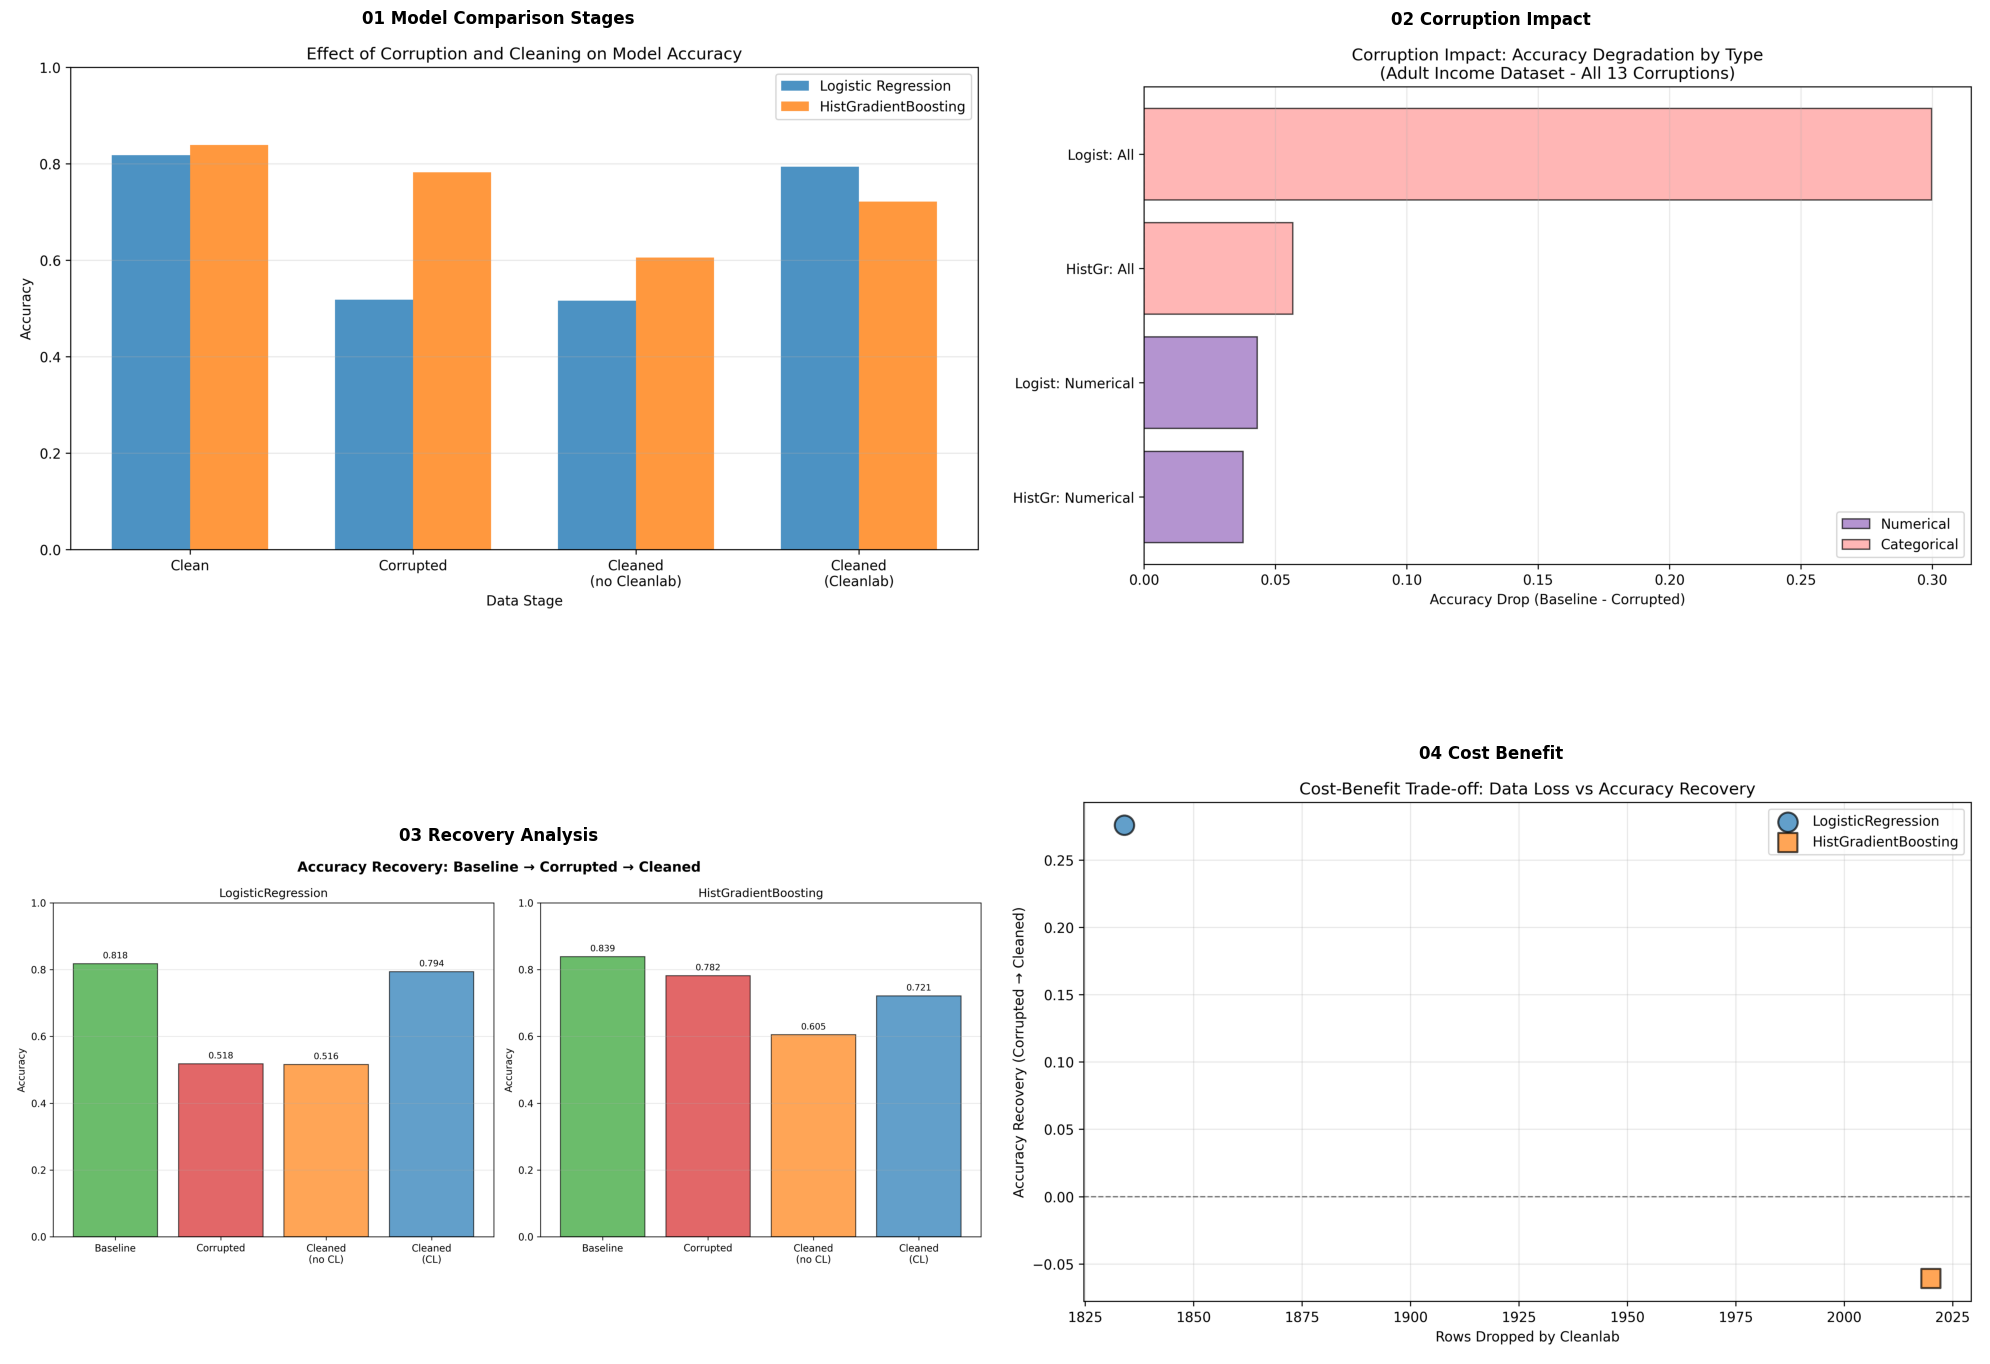


All figures displayed above
Combined preview saved to: /content/drive/MyDrive/adults-only-data_preparation_project_2026/results/figures/ALL_FIGURES_PREVIEW.png


In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os

BASE_DIR = "/content/drive/MyDrive/adults-only-data_preparation_project_2026"
FIGURES_DIR = os.path.join(BASE_DIR, "results/figures")

figures = [
    '01_model_comparison_stages.png',
    '02_corruption_impact.png',
    '03_recovery_analysis.png',
    '04_cost_benefit.png'
]

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for idx, fig_name in enumerate(figures):
    img_path = os.path.join(FIGURES_DIR, fig_name)

    if os.path.exists(img_path):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(fig_name.replace('_', ' ').replace('.png', '').title(),
                           fontsize=12, fontweight='bold', pad=10)
        print(f"Loaded: {fig_name}")
    else:
        axes[idx].text(0.5, 0.5, f'Not found:\n{fig_name}',
                      ha='center', va='center', fontsize=12)
        axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ALL_FIGURES_PREVIEW.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nAll figures displayed above")
print(f"Combined preview saved to: {os.path.join(FIGURES_DIR, 'ALL_FIGURES_PREVIEW.png')}")

In [11]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = "/content/drive/MyDrive/adults-only-data_preparation_project_2026"
RESULTS_CSV = os.path.join(BASE_DIR, "results/ALL_RESULTS_ADULT_COMBINED_FINAL.csv")
STATS_DIR = os.path.join(BASE_DIR, "results/statistical_tests")
FIGURES_DIR = os.path.join(BASE_DIR, "results/figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

print("="*60)
print("ADULT DATASET: COST-BENEFIT ANALYSIS")
print("="*60)

df = pd.read_csv(RESULTS_CSV)

# Load statistical test results
recovery_df = pd.read_csv(os.path.join(STATS_DIR, "02_accuracy_recovery.csv"))
cost_benefit_df = pd.read_csv(os.path.join(STATS_DIR, "03_cost_benefit_cleanlab.csv"))

print("\nGoal: Evaluate trade-off between accuracy gain and data sacrifice")

# Metric Consistency Analysis
print("\n" + "="*60)
print("METRIC CONSISTENCY ANALYSIS")
print("="*60)

consistency = []

for model in ['LogisticRegression', 'HistGradientBoosting']:
    model_data = df[df['model'] == model]

    baseline = model_data[model_data['cleaning_name']=='0_Baseline'].iloc[0]
    corrupted = model_data[model_data['cleaning_name']=='1_Corrupted_All'].iloc[0]
    cleaned_cl = model_data[model_data['cleaning_name']=='3_Cleaned_Cleanlab'].iloc[0]

    gains = {
        'accuracy': cleaned_cl['accuracy'] - corrupted['accuracy'],
        'precision': cleaned_cl['precision'] - corrupted['precision'],
        'recall': cleaned_cl['recall'] - corrupted['recall'],
        'f1': cleaned_cl['f1'] - corrupted['f1']
    }

    consistency.append({
        'Model': model,
        'Accuracy_Gain': gains['accuracy'],
        'Precision_Gain': gains['precision'],
        'Recall_Gain': gains['recall'],
        'F1_Gain': gains['f1'],
        'All_Positive': all(v > 0 for v in gains.values()),
        'Gain_Range': max(gains.values()) - min(gains.values())
    })

df_consistency = pd.DataFrame(consistency)

all_improved = df_consistency['All_Positive'].sum()
print(f"\nModels where ALL metrics improved: {all_improved}/{len(df_consistency)}")
print(f"\nAverage gains (Corrupted -> Cleaned with Cleanlab):")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    avg = df_consistency[f'{metric}_Gain'].mean()
    print(f"   {metric:10s}: {avg:+.4f}")

# Cost-Benefit Table
print("\n" + "="*60)
print("COST-BENEFIT TABLE")
print("="*60)

cost_benefit_analysis = []

for model in ['LogisticRegression', 'HistGradientBoosting']:
    model_data = df[df['model'] == model]

    baseline = model_data[model_data['cleaning_name']=='0_Baseline'].iloc[0]
    corrupted = model_data[model_data['cleaning_name']=='1_Corrupted_All'].iloc[0]
    cleaned_cl = model_data[model_data['cleaning_name']=='3_Cleaned_Cleanlab'].iloc[0]

    # Benefit: Accuracy recovery
    acc_gain = cleaned_cl['accuracy'] - corrupted['accuracy']
    damage = baseline['accuracy'] - corrupted['accuracy']
    recovery_pct = (acc_gain / damage * 100) if damage > 0 else 0

    # Cost: Data loss
    rows_dropped = abs(cleaned_cl['rows_dropped'])
    data_loss_pct = (rows_dropped / corrupted['n_samples_after']) * 100

    # Cost-Benefit Ratio (accuracy points gained per 1% data lost)
    cb_ratio = (acc_gain * 100) / data_loss_pct if data_loss_pct > 0 else 0

    # Value assessment
    if cb_ratio > 1.0 and acc_gain > 0:
        value = "Excellent"
    elif cb_ratio > 0.5 and acc_gain > 0:
        value = "Good"
    elif cb_ratio > 0 and acc_gain > 0:
        value = "Fair"
    else:
        value = "Poor"

    cost_benefit_analysis.append({
        'Model': model,
        'Damage': f"{damage:.3f}",
        'Accuracy_Gain': f"{acc_gain:.3f}",
        'Recovery_Pct': f"{recovery_pct:.1f}%",
        'Rows_Dropped': int(rows_dropped),
        'Data_Loss_Pct': f"{data_loss_pct:.1f}%",
        'CB_Ratio': f"{cb_ratio:.3f}",
        'Value': value,
        'Damage_Float': damage,
        'Acc_Gain_Float': acc_gain,
        'Data_Loss_Float': data_loss_pct,
        'CB_Ratio_Float': cb_ratio
    })

df_cb = pd.DataFrame(cost_benefit_analysis)

print("\n" + df_cb[['Model', 'Damage', 'Accuracy_Gain', 'Recovery_Pct',
                      'Data_Loss_Pct', 'CB_Ratio', 'Value']].to_string(index=False))

# Summary
print("\n" + "="*60)
print("COST-BENEFIT SUMMARY")
print("="*60)

print(f"\nOverall Statistics:")
print(f"   Average accuracy gain: {df_cb['Acc_Gain_Float'].mean():.3f}")
print(f"   Average data loss: {df_cb['Data_Loss_Float'].mean():.1f}%")
print(f"   Average CB ratio: {df_cb['CB_Ratio_Float'].mean():.3f}")

print(f"\nValue Distribution:")
for value_cat in ['Excellent', 'Good', 'Fair', 'Poor']:
    count = len(df_cb[df_cb['Value'] == value_cat])
    print(f"   {value_cat:10s}: {count}/2")

# Decision Framework
print("\n" + "="*60)
print("DECISION FRAMEWORK")
print("="*60)

print("\nWhen to use Cleanlab:")

for _, row in df_cb.iterrows():
    model_short = row['Model'][:6]
    if row['Value'] in ['Excellent', 'Good']:
        print(f"\n   {model_short}: RECOMMENDED")
        print(f"      Gain: {row['Accuracy_Gain']}, Loss: {row['Data_Loss_Pct']}, Ratio: {row['CB_Ratio']}")
    else:
        print(f"\n   {model_short}: NOT RECOMMENDED")
        print(f"      Gain: {row['Accuracy_Gain']}, Loss: {row['Data_Loss_Pct']}, Ratio: {row['CB_Ratio']}")

# Save
cb_path = os.path.join(BASE_DIR, "results/cost_benefit_analysis.csv")
df_cb.to_csv(cb_path, index=False)
print(f"\nSaved: {cb_path}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cost-Benefit Analysis: Cleanlab Cleaning', fontsize=14, fontweight='bold')

# Plot 1: Metric gains comparison
ax1 = axes[0, 0]
metrics = ['Accuracy_Gain', 'Precision_Gain', 'Recall_Gain', 'F1_Gain']
x = np.arange(len(metrics))
width = 0.35

logreg_gains = [df_consistency[df_consistency['Model']=='LogisticRegression'][m].values[0] for m in metrics]
gradboost_gains = [df_consistency[df_consistency['Model']=='HistGradientBoosting'][m].values[0] for m in metrics]

ax1.bar(x - width/2, logreg_gains, width, label='LogisticRegression', alpha=0.8)
ax1.bar(x + width/2, gradboost_gains, width, label='HistGradientBoosting', alpha=0.8)
ax1.set_ylabel('Metric Gain')
ax1.set_title('(A) Metric Improvements')
ax1.set_xticks(x)
ax1.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1'])
ax1.legend()
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Cost-Benefit Ratio
ax2 = axes[0, 1]
models = df_cb['Model'].values
cb_ratios = df_cb['CB_Ratio_Float'].values
colors = ['#2ca02c' if v == 'Excellent' else '#ff7f0e' if v == 'Good' else '#d62728'
          for v in df_cb['Value']]

ax2.barh(range(len(models)), cb_ratios, color=colors, alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(models)))
ax2.set_yticklabels([m[:15] for m in models])
ax2.set_xlabel('Cost-Benefit Ratio\n(Accuracy points per 1% data lost)')
ax2.set_title('(B) Cost-Benefit Efficiency')
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Good threshold')
ax2.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Excellent threshold')
ax2.legend(fontsize=8)

# Plot 3: Data Loss vs Accuracy Gain
ax3 = axes[1, 0]
scatter = ax3.scatter(df_cb['Data_Loss_Float'], df_cb['Acc_Gain_Float']*100,
                     s=300, alpha=0.6, c=df_cb['CB_Ratio_Float'],
                     cmap='RdYlGn', edgecolors='black', linewidth=2)

for idx, row in df_cb.iterrows():
    ax3.annotate(row['Model'][:6],
                (row['Data_Loss_Float'], row['Acc_Gain_Float']*100),
                fontsize=9, ha='center', va='bottom')

ax3.set_xlabel('Data Loss (%)')
ax3.set_ylabel('Accuracy Gain (% points)')
ax3.set_title('(C) Trade-off: Data Loss vs Accuracy Gain')
ax3.grid(alpha=0.3)
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5)

cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('CB Ratio')

# Plot 4: Recovery percentage
ax4 = axes[1, 1]
recovery_pcts = [float(r.replace('%', '')) for r in df_cb['Recovery_Pct']]
bars = ax4.bar(range(len(models)), recovery_pcts, color=['#1f77b4', '#ff7f0e'], alpha=0.7, edgecolor='black')

ax4.set_xticks(range(len(models)))
ax4.set_xticklabels([m[:15] for m in models], rotation=15, ha='right')
ax4.set_ylabel('Recovery (%)')
ax4.set_title('(D) Accuracy Recovery Rate\n(% of damage recovered)')
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='Full recovery')
ax4.legend()

for bar, val in zip(bars, recovery_pcts):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.0f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, '05_cost_benefit_analysis.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Saved figure: {fig_path}")
plt.close()

print("\n" + "="*60)
print("KEY TAKEAWAY")
print("="*60)

best = df_cb.loc[df_cb['CB_Ratio_Float'].idxmax()]
worst = df_cb.loc[df_cb['CB_Ratio_Float'].idxmin()]

print(f"\nBest performer: {best['Model']}")
print(f"   CB Ratio: {best['CB_Ratio']}")
print(f"   {best['Accuracy_Gain']} accuracy gain for {best['Data_Loss_Pct']} data loss")

print(f"\nWorst performer: {worst['Model']}")
print(f"   CB Ratio: {worst['CB_Ratio']}")
print(f"   {worst['Accuracy_Gain']} accuracy gain for {worst['Data_Loss_Pct']} data loss")

print("\nRECOMMENDATION:")
if best['CB_Ratio_Float'] > 1.0:
    print(f"   Cleanlab is highly effective for {best['Model']}")
else:
    print(f"   Cleanlab shows moderate effectiveness")

if worst['CB_Ratio_Float'] < 0:
    print(f"   Cleanlab HURTS performance for {worst['Model']}")

print("\n" + "="*60)

ADULT DATASET: COST-BENEFIT ANALYSIS

Goal: Evaluate trade-off between accuracy gain and data sacrifice

METRIC CONSISTENCY ANALYSIS

Models where ALL metrics improved: 1/2

Average gains (Corrupted -> Cleaned with Cleanlab):
   Accuracy  : +0.1075
   Precision : +0.0921
   Recall    : +0.1075
   F1        : +0.1824

COST-BENEFIT TABLE

               Model Damage Accuracy_Gain Recovery_Pct Data_Loss_Pct CB_Ratio     Value
  LogisticRegression  0.300         0.276        92.1%          8.3%    3.311 Excellent
HistGradientBoosting  0.057        -0.061      -107.6%          9.2%   -0.664      Poor

COST-BENEFIT SUMMARY

Overall Statistics:
   Average accuracy gain: 0.108
   Average data loss: 8.8%
   Average CB ratio: 1.324

Value Distribution:
   Excellent : 1/2
   Good      : 0/2
   Fair      : 0/2
   Poor      : 1/2

DECISION FRAMEWORK

When to use Cleanlab:

   Logist: RECOMMENDED
      Gain: 0.276, Loss: 8.3%, Ratio: 3.311

   HistGr: NOT RECOMMENDED
      Gain: -0.061, Loss: 9.2%, 

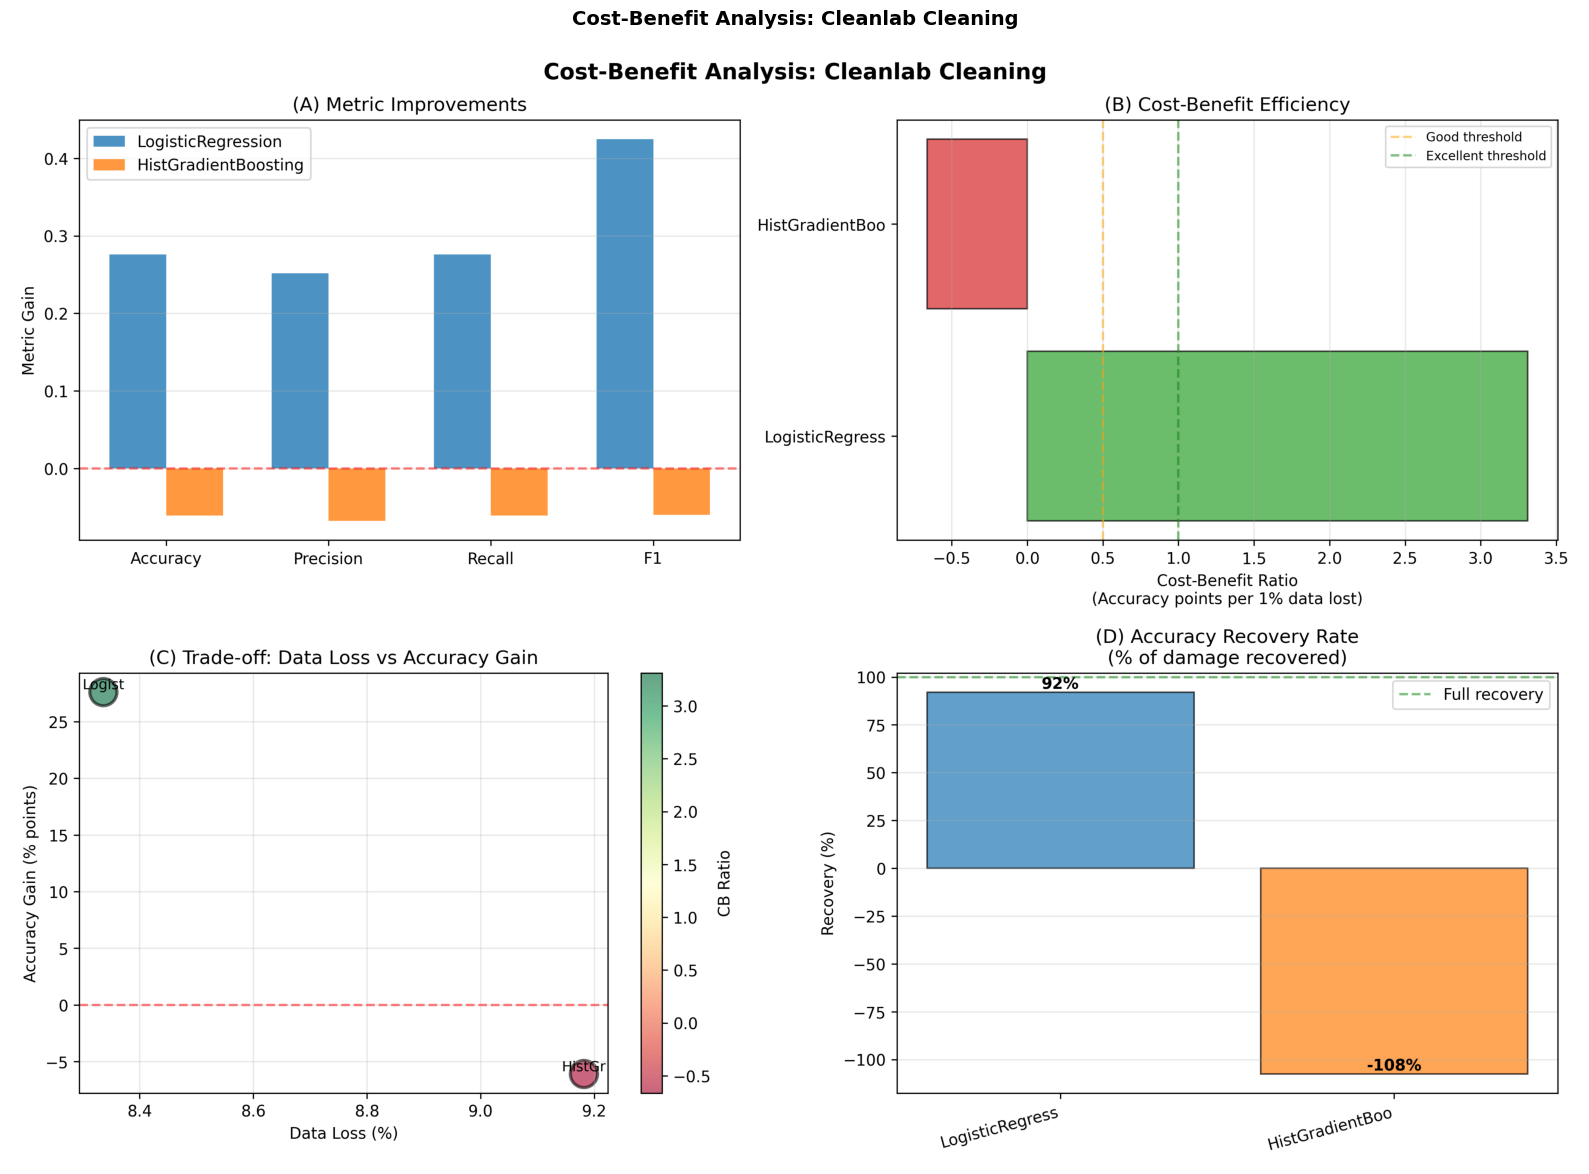

Figure loaded successfully
Path: /content/drive/MyDrive/adults-only-data_preparation_project_2026/results/figures/05_cost_benefit_analysis.png

All available figures:
   1. 01_model_comparison_stages.png
   2. 02_corruption_impact.png
   3. 03_recovery_analysis.png
   4. 04_cost_benefit.png
   5. 05_cost_benefit_analysis.png
   6. ALL_FIGURES_PREVIEW.png


In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import os

BASE_DIR = "/content/drive/MyDrive/adults-only-data_preparation_project_2026"
FIGURES_DIR = os.path.join(BASE_DIR, "results/figures")

fig_path = os.path.join(FIGURES_DIR, '05_cost_benefit_analysis.png')

if os.path.exists(fig_path):
    img = Image.open(fig_path)

    plt.figure(figsize=(16, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Cost-Benefit Analysis: Cleanlab Cleaning', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    print("Figure loaded successfully")
    print(f"Path: {fig_path}")

    # Also show all available figures
    print("\nAll available figures:")
    all_figs = sorted([f for f in os.listdir(FIGURES_DIR) if f.endswith('.png')])
    for idx, fig_name in enumerate(all_figs, 1):
        print(f"   {idx}. {fig_name}")
else:
    print(f"Figure not found at: {fig_path}")